# Prosody-Syntax Distributional Analysis

This notebook builds a co-occurrence matrix of (lemma, POS) tags against a mix of
**syntactic** and **prosodic** features extracted from the SUD-French-Rhapsodie
treebank. From that matrix we derive three parallel views — syntactic-only,
prosodic-only, and combined — and use each to compute:

1. **Similarity scores** between lexical units
2. A **per-unit purity / entropy / rival-category** score
3. A **category-level transition matrix** (how categories bleed into each other)
4. **Bridge words** — units whose neighbourhood pulls them toward a different POS
5. **Pulling features** — the features responsible for that pull
6. A global **weighted-average stability** for each feature space: syntactic, prosodic or both

The key cleanup vs. the original notebook: every downstream analysis takes a
`space` selector ∈ `{"syntactic", "prosodic_syntactic", "prosody_pure", "combined",
"prosodic_foot", "prosodic_group", "prosodic_package", "prosodic_period",
"prosodic_all_levels"}`, so swapping feature
spaces is a one-line change.

In [3]:
import sys
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from scipy.stats import entropy
from sklearn.metrics.pairwise import cosine_similarity

# ── Paths ──────────────────────────────────────────────────────────────────
TOD_PATH      = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod"
GREX_PATH     = "/Users/madalina/Documents/M2TAL/stage/grex/grex2"
TREEBANK_PATH = "/Users/madalina/Documents/PHD/code/data/SUD_French-Rhapsodie/prosody_no_punct.conllu"
# TREEBANK_PATH = "/Users/madalina/Documents/PHD/code/data/pSUD_Naija-NSC"
PATTERNS_FILE = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/3. probability_matrix/patterns_all_nodes_prosody.txt"

GREW_PATTERN      = "pattern{X[upos<>PUNCT]}"

# ── Bring third-party packages onto the path ───────────────────────────────
for p in (TOD_PATH, GREX_PATH):
    if p not in sys.path:
        sys.path.insert(1, p)

import pyximport
pyximport.install()

import grewpy
from grewpy import Corpus, CorpusDraft, Request

import tod.corpus  # noqa: F401  (registers handlers; keep import)

import grex.data           # noqa: F401
import grex.utils
import grex.features       # noqa: F401
import grex.data_prosody

grewpy.set_config("sud")


connected to port: 49795


In [4]:
# ── Drop entirely: redundant, unreliable, or too fine-grained ─────────────
FEATURES_TO_DROP = {
    'MeanF0',           # use SemitonesFromUtteranceMean instead (speaker-normalised)
    'MeanF0Step',       # threshold artefact, not a prosodic observation
    'AvgAmplitude',     # recording-condition-dependent
    'MaxAmplitude',     # same
    'SylForm',          # phonetic transcription, too fine-grained
    'AlignBegin',       # timing offset, not linguistic
    'AlignEnd',         # timing offset, not linguistic
    'pauseID',          # identifier, not a feature
    # Before*/Next* equivalents of dropped features:
    'BeforeMeanF0', 'BeforeMeanF0Step', 'BeforeAvgAmplitude',
    'NextMeanF0',   'NextMeanF0Step',   'NextAvgAmplitude',
    'Semiton', 'Overlap', 'Loc', 'Glo', 'Backchannel',
    "AvgAmplitudeNormalized", "Nucleus", "Onset", "MeanF0GlobalZscore", "MeanF0LocalZscore", "MeanF0Normalized"
}

# ── Bin into 3 quantile-based categories ──────────────────────────────────
# Note: Duration appears in TWO units in the data:
#   - syllable subnodes: integer ms     (e.g. 289, 167)
#   - pause nodes:       float seconds  (e.g. 0.2695, 0.3328)
# We normalise to ms before binning — see `_normalise_duration` below.
FEATURES_TO_BIN = {
    'SemitonesFromUtteranceMean',
    'Duration',
    'BeforeSemitonesFromUtterance',
    'NextSemitonesFromUtterance',
    'BeforeDuration',
    'NextDuration',
    'BeforeSemiton',
    'NextSemiton',
    'NextSemitonsFromUtterance',
    'NextBreakLength',
    'AvgAmplitudeGlobalZscore', # naija
    # naija
    "DurationGlobalZscore" # naija
}

BIN_LABELS = {
    'SemitonesFromUtteranceMean':   ['F0_low',       'F0_mid',       'F0_high'],
    'Duration':                     ['Dur_short',    'Dur_mid',      'Dur_long'],
    'BeforeSemitonesFromUtterance': ['BeforeF0_low', 'BeforeF0_mid', 'BeforeF0_high'],
    'NextSemitonesFromUtterance':   ['NextF0_low',   'NextF0_mid',   'NextF0_high'],
    'NextBreakLength':              ['NextBreak_short', 'NextBreak_mid', 'NextBreak_long'],
    
}


In [5]:
# ── SLAM3 contour decomposition ───────────────────────────────────────────
# The *Tone features (FootTone, GroupTone, PackageTone, Period_tone) encode
# pitch contours compositionally:
#
#     [start_pitch][end_pitch]            -- no salient peak (2 chars)
#     [start_pitch][end_pitch][peak][tier] -- with salient peak (4 chars)
#
# pitch ∈ {L, l, m, h, H}  (5 ordinal levels: very low → very high)
# tier  ∈ {1, 2, 3}        (which syllabic tier carries the peak)
# Plus the special atomic value 'Pause'.
#
# Treating these as opaque strings gives ~300 sparse one-hot columns per
# *Tone feature. Decomposing into {start, end, peak, tier, has_peak,
# direction, magnitude} yields ~5 dense sub-features per token instead.

SLAM_TONE_FEATURES = {'FootTone', 'GroupTone', 'PackageTone', 'Period_tone', 'Period', 'PeriodTone'}

# Ordinal mapping used to derive direction & magnitude.
_PITCH_LEVELS = {'L': 1, 'l': 2, 'm': 3, 'h': 4, 'H': 5}
_TIERS = {'1', '2', '3'}


def _parse_slam(label):
    """Parse a SLAM3 contour string into its components.

    Returns a dict {pause, start, end, peak, tier} or None if the label
    doesn't match the SLAM3 grammar (silently skipped downstream).
    """
    if label == 'Pause':
        return {'pause': True, 'start': None, 'end': None,
                'peak': None, 'tier': None}

    if (len(label) == 2
            and label[0] in _PITCH_LEVELS and label[1] in _PITCH_LEVELS):
        return {'pause': False, 'start': label[0], 'end': label[1],
                'peak': None, 'tier': None}

    if (len(label) == 4
            and label[0] in _PITCH_LEVELS and label[1] in _PITCH_LEVELS
            and label[2] in _PITCH_LEVELS and label[3] in _TIERS):
        return {'pause': False, 'start': label[0], 'end': label[1],
                'peak': label[2], 'tier': label[3]}

    return None


def _slam_subfeatures(prefix, label):
    """Yield 'sub-feature=value' strings derived from a SLAM3 contour label.

    `prefix` is the path up to and including the *Tone name,
    e.g. 'node:X:child:GroupTone'. Sub-features become
    'node:X:child:GroupTone:start=H', 'node:X:child:GroupTone:direction=rise', …
    """
    parsed = _parse_slam(label)
    if parsed is None:
        return

    if parsed['pause']:
        yield f"{prefix}:pause=True"
        return

    s, e = parsed['start'], parsed['end']
    yield f"{prefix}:start={s}"
    yield f"{prefix}:end={e}"

    # Direction & magnitude on the ordinal pitch scale.
    delta = _PITCH_LEVELS[e] - _PITCH_LEVELS[s]
    if delta > 0:
        direction = 'rise'
    elif delta < 0:
        direction = 'fall'
    else:
        direction = 'flat'
    yield f"{prefix}:direction={direction}"
    yield f"{prefix}:magnitude={abs(delta)}"

    if parsed['peak'] is not None:
        yield f"{prefix}:has_peak=True"
        yield f"{prefix}:peak={parsed['peak']}"
        yield f"{prefix}:tier={parsed['tier']}"
    else:
        yield f"{prefix}:has_peak=False"

In [6]:
def _normalise_duration(value_str):
    """Convert a Duration string to milliseconds regardless of source node type.

    Syllable subnodes store ms (e.g. '289'); pause nodes store seconds
    (e.g. '0.2695'). Heuristic: values < 10 are seconds. A literal 0.0 means
    'missing' (e.g. overlap nodes) → returns None.
    """
    try:
        v = float(value_str)
    except (ValueError, TypeError):
        return None
    if v == 0.0:
        return None
    return v * 1000 if v < 10 else v


def _is_sentinel(value_str):
    """True for the '0.0' sentinel that overlap / missing pause nodes carry.

    Without this guard, those zeros would be binned as F0_low rather than
    silently dropped.
    """
    try:
        return float(value_str) == 0.0
    except (ValueError, TypeError):
        return False


def _feature_name(key):
    """Bare feature name from a path-like key, e.g. ('node','X','child','Duration') → 'Duration'."""
    return key[-1]


In [7]:
def collect_continuous_values(all_data_items):
    """Walk every (lex_unit, match, features) triple and collect raw float
    values for each feature in FEATURES_TO_BIN.

    Returns: {feature_name: [float, ...]}
    """
    collector = {f: [] for f in FEATURES_TO_BIN}

    for _, _, features in all_data_items:
        for key, value in features.items():
            fname = _feature_name(key)
            if fname not in FEATURES_TO_BIN:
                continue
            # `value` is a string for own/parent/prev/next, or a set of strings
            # for child (a node can have multiple syllables).
            values = value if isinstance(value, set) else {value}
            for v in values:
                if fname == 'Duration':
                    norm = _normalise_duration(v)
                    if norm is not None:
                        collector['Duration'].append(norm)
                elif not _is_sentinel(v):
                    try:
                        collector[fname].append(float(v))
                    except (ValueError, TypeError):
                        pass
    return collector


def compute_thresholds(collector, n_bins=3):
    """Quantile boundaries (interior only) per feature.

    Returns: {feature_name: [boundary_1, boundary_2, ...]}
    """
    thresholds = {}
    for fname, values in collector.items():
        if not values:
            continue
        arr = np.array(values)
        quantiles = np.linspace(0, 1, n_bins + 1)[1:-1]
        thresholds[fname] = np.quantile(arr, quantiles).tolist()
    return thresholds


In [8]:
def _bin_value(fname, value_str, thresholds):
    """Continuous string → bin label. Returns None for sentinels / unknowns."""
    if fname not in thresholds or _is_sentinel(value_str):
        return None

    if fname == 'Duration':
        v = _normalise_duration(value_str)
    else:
        try:
            v = float(value_str)
        except (ValueError, TypeError):
            return None

    if v is None:
        return None

    bounds = thresholds[fname]
    labels = BIN_LABELS.get(fname, [f'{fname}_Q1', f'{fname}_Q2', f'{fname}_Q3'])
    for i, b in enumerate(bounds):
        if v <= b:
            return labels[i]
    return labels[-1]


def format_features(features, thresholds):
    """Turn a feature dict into a list of 'k1:k2:...:kn=value' strings.

    Continuous features are binned; dropped features are skipped.
    """
    result = []
    for key, value in features.items():
        fname = _feature_name(key)
        prefix = ':'.join(key)

        if fname in FEATURES_TO_DROP:
            continue

        if fname in FEATURES_TO_BIN:
            values = value if isinstance(value, set) else {value}
            for v in values:
                label = _bin_value(fname, v, thresholds)
                if label is not None:
                    result.append(f"{prefix}={label}")
            continue
        
        # if fname == 'Period':
        #     # Strip *, -, and prefix/suffix markers to collapse 16 values down to 4.
        #     for v in values:
        #         cleaned = v.strip('*-')
        #         result.append(f"{prefix}={cleaned}")
        #     # If you want to preserve the pause-adjacency information as its own
        #     # feature, add a boolean:
        #     if any('*' in v or '-' in v for v in values):
        #         result.append(f"{prefix}_pause_adjacent=True")
        #     continue
        
        # SLAM3 contour features: decompose into structural sub-features.
        if fname in SLAM_TONE_FEATURES:
            values = value if isinstance(value, set) else {value}
            for v in values:
                result.extend(_slam_subfeatures(prefix, v))
            continue


        # Categorical: keep as-is.
        if isinstance(value, set):
            for v in value:
                result.append(f"{prefix}={v}")
        else:
            result.append(f"{prefix}={value}")

    return result


def _filter_features(features, excluded_patterns=None, included_patterns=None):
    """Regex-based include/exclude filter over a list of feature strings."""
    import re
    out = []
    for feature in features:
        if excluded_patterns and any(re.search(p, feature) for p in excluded_patterns):
            continue
        if included_patterns and not any(re.search(p, feature) for p in included_patterns):
            continue
        out.append(feature)
    return out


In [42]:
corpus = grewpy.Corpus(TREEBANK_PATH)
draft  = grewpy.CorpusDraft(corpus)

all_matches = corpus.search(
    grewpy.Request(GREW_PATTERN)
        .without("X[InIdiom=Yes]")
        .without("X[Idiom=Yes]")
        .without("X[InTitle=Yes]")
        .without("X[Title=Yes]")
        .without("X[Scrap=Yes]")
        .without("X[Foreign]")
        .without("X[Lang]")
        .without("X-[fixed]->Y")
        .without("Y-[flat:name]->X")
        .without("Y-[goeswith]->X"),
    clustering_keys=["X.form"],
)

# Drop lemmas with fewer than 10 occurrences.
# matches = {k: v for k, v in all_matches.items() if len(v) > 10}
matches=all_matches

# sent_id → {node_id: features}
sent_id_to_sentence = {
    draft[i].meta["sent_id"]: draft[i].features for i in range(len(draft))  # type: ignore
}

print(f"Lemmas after frequency filter: {len(matches)}")


Lemmas after frequency filter: 4567


In [43]:
# Re-key by (lemma, POS). Use ExtPos when present (e.g. '%' has upos=SYM but
# ExtPos=NOUN, and we want NOUN). Otherwise fall back to upos.
match_upos = {}
for lemma, occurrences in matches.items():
    for m in occurrences:
        sent_id = m["sent_id"]
        node_id = str(m["matching"]["nodes"]["X"])
        sentence_features = sent_id_to_sentence.get(sent_id)
        if sentence_features is None or node_id not in sentence_features:
            continue
        token_features = sentence_features[node_id]
        if "ExtPos" in token_features:
            pos = token_features["ExtPos"]
        elif "upos" in token_features:
            pos = token_features["upos"]
        else:
            print(f"WARNING: lemma '{lemma}' in '{sent_id}' has no upos.")
            continue
        match_upos.setdefault((lemma, pos), []).append(m)

# Filter again post-split: a lemma may have passed at the lemma level but
# split into rare (lemma, POS) pairs.
# match_upos = {k: v for k, v in match_upos.items() if len(v) > 10}

print(f"(lemma, POS) units after frequency filter: {len(match_upos)}")


(lemma, POS) units after frequency filter: 4880


In [44]:
# Load the feature template config and run feature extraction over every match.
with open(PATTERNS_FILE) as f:
    config = yaml.load(f, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(
    config["features"], templates=templates,
)

all_data_items = []
for lex_unit, mts in match_upos.items():
    for match in mts:
        feats = grex.data_prosody.extract_features(draft, match, feature_predicate)
        all_data_items.append((lex_unit, match, feats))

print(f"Total (lex_unit, match, features) triples: {len(all_data_items)}")


Total (lex_unit, match, features) triples: 33175


In [45]:
# Compute corpus-wide quantile thresholds, then format every match's features
# (binning the continuous ones, dropping the unwanted ones).
collector  = collect_continuous_values(all_data_items)
thresholds = compute_thresholds(collector, n_bins=3)

print("Computed thresholds:")
for fname, bounds in thresholds.items():
    labels = BIN_LABELS.get(fname, ['Q1', 'Q2', 'Q3'])
    print(
        f"  {fname}: <{bounds[0]:.3f} → {labels[0]} | "
        f"<{bounds[1]:.3f} → {labels[1]} | ≥{bounds[1]:.3f} → {labels[2]}"
    )

# Drop 'own' features (the focused node's own attributes — they trivially
# determine its category and would dominate similarity).
EXCLUDED_FEATURE_PATTERNS = [# Own features that would trivially recover POS or aren't prosodic
    'upos', 'lemma', 'form',
    'rel_shallow', 'deprel',
    'Case', 'Definite', 'Gender', 'Mood',
    'Number', 'NumType', 'Person', 'Polarity',
    'Poss', 'PronType', 'Reflex', 'Tense',
    'VerbForm', 'Voice',
    'Number[lex]', 'Person[lex]',
    'Gender[ctxt]', 'Number[ctxt]',
    'ExtPos', 'Foreign', 'Lang', 'Emph',
    'HasSpokenGender', 'HasSpokenNumber',
    'AlignBegin', 'AlignEnd', 'SylForm', 'SpaceAfter',
    # Unmeasurable slope
    'Slope=X',
    # Fused: rare and per-syllable, drops signal-to-noise
    'Fused=Yes',
    # Redundant local slope (keep the Glo scope)
    ':Slope=',
    # Morphological features of dependents — clutter the syntactic space
    'own:Filler=', "Token2=", "rel_deep=", "__MISC__Rel=", "TypePara=", "TypeInherited=", "Truncated=", "Subject=", "Token3", "Token4", "ProminenceFinal=0", "ProminenceInitial=0", "UtteranceMeanF0=0.0",
    "IU", "nucleus", "Layer", "Filler=", "Shared",     
    'ExtPos', "Loc=", "direction=flat", "has_peak=False", "FootTone:pause", "GroupTone:pause", "PackageTone:pause", "Period_tone:pause", "ProminenceFinal=Pause", "ProminenceInitial=Pause",
                             "AvgAmplitudeLocalZscore", "DurationLocalZscore", "MaxAmplitudeLocalZscore", "DurationNormalized", "MaxAmplitudeGlobalZscore", 
                             "Nucleus", "Onset", "MeanF0GlobalZscore", "MeanF0LocalZscore", "MeanF0Normalized", "MaxAmplitudeNormalized", "Coda"
                             ]

data = {k: [] for k in match_upos}
for lex_unit, _, features in all_data_items:
    formatted = _filter_features(
        format_features(features, thresholds),
        excluded_patterns=EXCLUDED_FEATURE_PATTERNS,
    )
    data[lex_unit].append(formatted)


Computed thresholds:
  SemitonesFromUtteranceMean: <-1.278 → F0_low | <0.529 → F0_mid | ≥0.529 → F0_high
  Duration: <133.000 → Dur_short | <199.000 → Dur_mid | ≥199.000 → Dur_long
  NextBreakLength: <0.283 → NextBreak_short | <0.530 → NextBreak_mid | ≥0.530 → NextBreak_long


In [46]:
# Build index lookups. These are used everywhere downstream.
unique_lemma    = sorted(set(data))
unique_features = sorted({feat for lists in data.values() for fs in lists for feat in fs})

idx2feature = {i: feat for i, feat in enumerate(unique_features)}
feature2idx = {feat: i for i, feat in idx2feature.items()}
idx2lexunit = {i: feat for i, feat in enumerate(unique_lemma)}
lexunit2idx = {feat: i for i, feat in idx2lexunit.items()}

print(f"Lexical units: {len(idx2lexunit)} | features: {len(idx2feature)}")


Lexical units: 4880 | features: 11590


In [47]:
co_occurrence_matrix = np.zeros((len(idx2lexunit), len(idx2feature)))
for lex_unit, feature_lists in data.items():
    for feature_list in feature_lists:
        for feature in feature_list:
            co_occurrence_matrix[lexunit2idx[lex_unit], feature2idx[feature]] += 1

row_sums = co_occurrence_matrix.sum(axis=1)
coverage_matrix = np.divide(
    co_occurrence_matrix,
    row_sums[:, np.newaxis],
    out=np.zeros_like(co_occurrence_matrix),
    where=row_sums[:, np.newaxis] != 0,
)

feature_matrix = coverage_matrix


In [48]:
# ── Column-frequency filter ───────────────────────────────────────────────
# Drop feature columns that are non-zero on fewer than MIN_LEXUNITS lexical
# units. Such columns contribute mostly noise to cosine similarity (they look
# like spurious axes of variation between the few units that happen to use
# them) and bloat the matrix.
#
# Cosine similarity is scale-invariant, so we don't renormalise rows after
# dropping columns — within-row ratios are preserved.
MIN_LEXUNITS = 10

col_nonzero_per_lexunit = (co_occurrence_matrix > 0).sum(axis=0)
keep_cols = col_nonzero_per_lexunit >= MIN_LEXUNITS

n_before = feature_matrix.shape[1]
co_occurrence_matrix = co_occurrence_matrix[:, keep_cols]
feature_matrix       = feature_matrix[:, keep_cols]

# Rebuild the index lookups so they stay aligned with the matrix.
kept_features = [idx2feature[i] for i in range(n_before) if keep_cols[i]]
idx2feature   = {i: f for i, f in enumerate(kept_features)}
feature2idx   = {f: i for i, f in idx2feature.items()}

print(f"Dropped {n_before - int(keep_cols.sum())} columns "
      f"non-zero on <{MIN_LEXUNITS} lexical units.")
print(f"Remaining features: {int(keep_cols.sum())} / {n_before}")

Dropped 10692 columns non-zero on <10 lexical units.
Remaining features: 898 / 11590


In [49]:
# ── Feature-space masks ───────────────────────────────────────────────────
# Each space is a subset of columns of `feature_matrix`. Substring matching on
# the feature name decides which mask a column falls into — e.g. the marker
# 'Foot' catches 'Foot=Begin', 'FootTone:start=H', 'FootType=Strong' alike.
#
# Spaces:
#   syntactic          — every column NOT in PROSODIC_MARKERS (POS, deprel,
#                        morphology, IU/Nucleus position, …). Includes syntactic
#                        features attached to any position (parent, child,
#                        prev token, next token).
#   prosodic_syntactic — every column in PROSODIC_MARKERS. This mixes prosody
#                        with the syntactic environment: prosodic features
#                        attached to the token's parent, dependents, and
#                        linear neighbours count as prosodic here even though
#                        they involve the syntactic tree to locate them.
#   prosody_pure       — only prosodic features attached to the lex unit's own
#                        syllables (childSyl1, childSyl2, …) and the syllables
#                        immediately before and after (prevSyl, nextSyl) and the node immediately before, after and own. No
#                        features from the syntactic environment. This is the
#                        strictest "prosody without syntax" view.
#   prosodic_foot      — Foot / FootTone / FootType only
#   prosodic_group     — Group / GroupTone / RhythmGroup only
#   prosodic_package   — Package / PackageTone / Package_type only
#   prosodic_period    — Period / Period_tone only
#   prosodic_all_levels— union of the four per-level spaces above (i.e.
#                        structural prosodic only, no syllable acoustics)
#   combined           — every column

PROSODIC_MARKERS = (
    # syllable-level / continuous acoustic
    'childSyl', 'prevSyl', 'nextSyl',
    'Slope', 'Glo', 'Loc', 'Duration',
    'PitchRange', 'AvgHeight', 'Semiton',
    'F0', 'Fused',
    # token-level prosodic structural annotations
    'Foot', 'Group', 'Package', 'Period',
    'Prominence', 'Hesitation', 'RhythmGroup', 'NextBreakLength', 'IU', 'Nucleus'
)

# Markers for the strictest "prosody only" view: features on the lex unit's
# own syllables and its immediate prev/next syllable. Everything else — parent
# tokens, dependent tokens, prev/next tokens — is excluded, even if those
# features are themselves prosodic.
PROSODY_PURE_MARKERS = ('own', 'childSyl', 'prevSyl', 'nextSyl', 'prev:', 'next:',)

# Per-level markers for the prosodic ablation views. Substring matching
# naturally catches the *Tone:* and *Type variants:
#   'Foot'    → Foot, FootTone, FootType
#   'Group'   → Group, GroupTone, RhythmGroup
#   'Package' → Package, PackageTone, Package_type
#   'Period'  → Period, Period_tone
LEVEL_MARKERS = {
    'foot':    ('Foot',),
    'group':   ('Group',),
    'package': ('Package',),
    'period':  ('Period',),
}


def _mask_for(markers):
    return np.array([
        any(p in feat for p in markers)
        for feat in idx2feature.values()
    ])


prosodic_mask     = _mask_for(PROSODIC_MARKERS)
syntactic_mask    = ~prosodic_mask
prosody_pure_mask = _mask_for(PROSODY_PURE_MARKERS)
level_masks       = {lvl: _mask_for(m) for lvl, m in LEVEL_MARKERS.items()}
all_levels_mask   = np.any(np.stack(list(level_masks.values())), axis=0)

print(f"Syntactic           features: {int(syntactic_mask.sum())}")
print(f"Prosodic_syntactic  features: {int(prosodic_mask.sum())}")
print(f"Prosody_pure        features: {int(prosody_pure_mask.sum())}")
for lvl, m in level_masks.items():
    print(f"  prosodic_{lvl:<7s} features: {int(m.sum())}")
print(f"  prosodic_all_levels features: {int(all_levels_mask.sum())}")

# Cosine similarities for each space. `combined` uses the full matrix.
similarities = {
    "syntactic":           cosine_similarity(feature_matrix[:, syntactic_mask]),
    "prosodic_syntactic":  cosine_similarity(feature_matrix[:, prosodic_mask]),
    "prosody_pure":        cosine_similarity(feature_matrix[:, prosody_pure_mask]),
    # "prosodic_foot":       cosine_similarity(feature_matrix[:, level_masks['foot']]),
    # "prosodic_group":      cosine_similarity(feature_matrix[:, level_masks['group']]),
    # "prosodic_package":    cosine_similarity(feature_matrix[:, level_masks['package']]),
    # "prosodic_period":     cosine_similarity(feature_matrix[:, level_masks['period']]),
    # "prosodic_all_levels": cosine_similarity(feature_matrix[:, all_levels_mask]),
    "combined":            cosine_similarity(feature_matrix),
}

SPACE_MASKS = {
    "syntactic":           syntactic_mask,
    "prosodic_syntactic":  prosodic_mask,
    "prosody_pure":        prosody_pure_mask,
    # "prosodic_foot":       level_masks["foot"],
    # "prosodic_group":      level_masks["group"],
    # "prosodic_package":    level_masks["package"],
    # "prosodic_period":     level_masks["period"],
    # "prosodic_all_levels": all_levels_mask,
    "combined":            None,
}

Syntactic           features: 9
Prosodic_syntactic  features: 889
Prosody_pure        features: 584
  prosodic_foot    features: 190
  prosodic_group   features: 190
  prosodic_package features: 195
  prosodic_period  features: 135
  prosodic_all_levels features: 710


In [50]:
# features2pop = [618, 512, 727, 925, 4, 5, 40, 51, 52, 95, 96, 117, 153, 154, 155, 156, 196, 201, 306, 307, 
#                 342, 353, 354, 397, 398, 418, 454, 455, 456, 496, 501, 192, 197, 492, 497, 709, 713, 906, 910,   ]
# for f in features2pop:
#     try:
#         idx2feature.pop(f, None)
#     except KeyError:
#         print(f"Feature index {f} not found in idx2feature.")
    
prosodic_pure_features = [
    feat for i, feat in idx2feature.items()
    if prosody_pure_mask[i]
]

print(f"Prosodic_pure features: {len(prosodic_pure_features)}")
for feat in prosodic_pure_features:
    print(feat)

Prosodic_pure features: 584
node:X:childSyl1:AvgHeightGlo=H
node:X:childSyl1:AvgHeightGlo=L
node:X:childSyl1:AvgHeightGlo=M
node:X:childSyl1:Duration=Dur_long
node:X:childSyl1:Duration=Dur_mid
node:X:childSyl1:Duration=Dur_short
node:X:childSyl1:PitchRangeGlo=H
node:X:childSyl1:PitchRangeGlo=L
node:X:childSyl1:PitchRangeGlo=M
node:X:childSyl1:SemitonesFromUtteranceMean=F0_high
node:X:childSyl1:SemitonesFromUtteranceMean=F0_low
node:X:childSyl1:SemitonesFromUtteranceMean=F0_mid
node:X:childSyl1:SlopeGlo=Fall
node:X:childSyl1:SlopeGlo=Flat
node:X:childSyl1:SlopeGlo=Rise
node:X:childSyl2:AvgHeightGlo=H
node:X:childSyl2:AvgHeightGlo=L
node:X:childSyl2:AvgHeightGlo=M
node:X:childSyl2:Duration=Dur_long
node:X:childSyl2:Duration=Dur_mid
node:X:childSyl2:Duration=Dur_short
node:X:childSyl2:PitchRangeGlo=H
node:X:childSyl2:PitchRangeGlo=L
node:X:childSyl2:PitchRangeGlo=M
node:X:childSyl2:SemitonesFromUtteranceMean=F0_high
node:X:childSyl2:SemitonesFromUtteranceMean=F0_low
node:X:childSyl2:Semit

In [51]:
def find_own_only_features(feature_list):
    # Split each line into its components
    own_features = set()
    prev_features = set()
    next_features = set()

    for line in feature_list:
        if line.startswith("node:X:own:"):
            feature = line.split("node:X:own:")[1]
            own_features.add(feature)
        elif line.startswith("node:X:prev:"):
            feature = line.split("node:X:prev:")[1]
            prev_features.add(feature)
        elif line.startswith("node:X:next:"):
            feature = line.split("node:X:next:")[1]
            next_features.add(feature)

    # Find features only in own
    only_own = own_features - (prev_features | next_features)
    return sorted(only_own)

# Example usage:
# features = [ "node:X:own:Foot=Begin", "node:X:prev:Foot=Begin", ... ]
only_own = find_own_only_features(prosodic_pure_features)
print(only_own)

[]


In [52]:
prosodic_syntactic_features = [
    feat for i, feat in idx2feature.items()
    if prosodic_mask[i]
]
print(f"Prosodic_syntactic features: {len(prosodic_syntactic_features)}")
for feat in prosodic_syntactic_features:
    print(feat)

Prosodic_syntactic features: 889
node:X:child:Foot=Begin
node:X:child:Foot=In
node:X:child:Foot=Last
node:X:child:Foot=Unique
node:X:child:FootTone:direction=fall
node:X:child:FootTone:direction=rise
node:X:child:FootTone:end=H
node:X:child:FootTone:end=L
node:X:child:FootTone:end=h
node:X:child:FootTone:end=l
node:X:child:FootTone:end=m
node:X:child:FootTone:has_peak=True
node:X:child:FootTone:magnitude=0
node:X:child:FootTone:magnitude=1
node:X:child:FootTone:magnitude=2
node:X:child:FootTone:magnitude=3
node:X:child:FootTone:magnitude=4
node:X:child:FootTone:peak=H
node:X:child:FootTone:peak=L
node:X:child:FootTone:peak=h
node:X:child:FootTone:peak=l
node:X:child:FootTone:peak=m
node:X:child:FootTone:start=H
node:X:child:FootTone:start=L
node:X:child:FootTone:start=h
node:X:child:FootTone:start=l
node:X:child:FootTone:start=m
node:X:child:FootTone:tier=1
node:X:child:FootTone:tier=2
node:X:child:FootTone:tier=3
node:X:child:FootType=Strong
node:X:child:FootType=Weak
node:X:child:Foo

In [53]:
# Global category frequencies — denominator of P_norm.
all_pos = [lu[1] for lu in idx2lexunit.values()]
total_pos_count = len(all_pos)
category_freqs = {cat: count / total_pos_count for cat, count in Counter(all_pos).items()}


def compute_scores(similarity, idx2lexunit, category_freqs,
                   sim_threshold=0.7, max_neighbours=20):
    """For every lexical unit, return purity / entropy / rival-category metrics
    based on the given similarity matrix.

    Returns: {(lemma, POS): {"purity", "entropy", "rival_category", "rival_weight_ratio"}}
    """
    scores = {}

    for idx, lex_unit in idx2lexunit.items():
        current_category = lex_unit[1]

        # 1. Top-k neighbours above similarity threshold (excluding self).
        candidate_idx = np.where(similarity[idx] >= sim_threshold)[0]
        neighbours = sorted(
            [i for i in candidate_idx if i != idx],
            key=lambda i: similarity[idx][i],
            reverse=True,
        )[:max_neighbours]

        if not neighbours:
            continue

        # 2. Sum similarity weight per category.
        category_weights = {}
        purity_bottom = 0.0
        for n_idx in neighbours:
            n_cat = idx2lexunit[n_idx][1]
            w = similarity[idx][n_idx]
            purity_bottom += w
            category_weights[n_cat] = category_weights.get(n_cat, 0) + w

        # 3. P_norm = (raw share) / (global frequency), then renormalise to sum to 1.
        norm_weights = {
            cat: (w / purity_bottom) / category_freqs[cat]
            for cat, w in category_weights.items()
        }
        total = sum(norm_weights.values())
        p_norm = {cat: v / total for cat, v in norm_weights.items()}

        # 4. Purity & entropy.
        purity_score  = p_norm.get(current_category, 0.0)
        entropy_score = entropy(list(p_norm.values()))

        # 5. Strongest non-self category.
        rival_cat = None
        rival_p   = 0.0
        for cat, p in p_norm.items():
            if cat != current_category and p > rival_p:
                rival_p   = p
                rival_cat = cat

        scores[lex_unit] = {
            "purity":             purity_score,
            "entropy":            entropy_score,
            "rival_category":     rival_cat,
            "rival_weight_ratio": rival_p,
        }

    return scores


In [54]:
# Compute scores for all three feature spaces in one pass. Pick whichever you
# want for downstream analysis.
scores_by_space = {
    space: compute_scores(sim, idx2lexunit, category_freqs)
    for space, sim in similarities.items()
}

print({space: len(s) for space, s in scores_by_space.items()})


{'syntactic': 4597, 'prosodic_syntactic': 2547, 'prosody_pure': 3012, 'combined': 2571}


In [55]:
# find word with lowest purity and lowest entropy in the prosody_pure space
prosody_pure_scores = scores_by_space["prosody_pure"]
lowest_purity_word = min(prosody_pure_scores.items(), key=lambda x: x[1]["purity"])
lowest_entropy_word = min(prosody_pure_scores.items(), key=lambda x: x[1]["entropy"])
print(f"Lowest purity word: {lowest_purity_word[0]} with purity {lowest_purity_word[1]['purity']}")
print(f"Lowest entropy word: {lowest_entropy_word[0]} with entropy {lowest_entropy_word[1]['entropy']}")

Lowest purity word: ('-moi', 'PRON') with purity 0.0
Lowest entropy word: ('-nous', 'PRON') with entropy 0.0


In [56]:
# show words with purity < 0.5 in the prosody_pure space
low_purity_words = {word: score for word, score in prosody_pure_scores.items() if score["purity"] < 0.5}
print(f"Words with purity < 0.5 in prosody_pure space: {len(low_purity_words)}")
for word, score in low_purity_words.items():
    print(f"{word}: purity={score['purity']}, entropy={score['entropy']}, rival_category={score['rival_category']}, rival_weight_ratio={score['rival_weight_ratio']}")

Words with purity < 0.5 in prosody_pure space: 2599
('-ce', 'PRON'): purity=0.37066464645105207, entropy=1.151638698162638, rival_category=AUX, rival_weight_ratio=0.48279182133454474
('-dessus', 'NOUN'): purity=0.08745945679428813, entropy=1.4003179044083665, rival_category=AUX, rival_weight_ratio=0.4622115952355936
('-il', 'PRON'): purity=0.10694631736164681, entropy=1.5826477149835863, rival_category=ADP, rival_weight_ratio=0.29656573327722585
('-ils', 'PRON'): purity=0.2091347637231078, entropy=1.1013397530905067, rival_category=AUX, rival_weight_ratio=0.4693278025656173
('-là', 'ADV'): purity=0.2809256254456627, entropy=1.2771378121536072, rival_category=PRON, rival_weight_ratio=0.517664647740607
('-moi', 'PRON'): purity=0.0, entropy=0.822031674690789, rival_category=ADV, rival_weight_ratio=0.6532151519125698
('-nous', 'PRON'): purity=0.0, entropy=0.0, rival_category=NOUN, rival_weight_ratio=1.0
('-on', 'PRON'): purity=0.20210175828422702, entropy=1.6811433218540182, rival_category

In [57]:
def build_transition_matrix(similarity, idx2lexunit, category_freqs,
                            sim_threshold=0.7, max_neighbours=20):
    """Square row-stochastic DataFrame indexed by POS category."""
    rows = []

    for idx, lex_unit in idx2lexunit.items():
        current_cat = lex_unit[1]

        candidate_idx = np.where(similarity[idx] > sim_threshold)[0]
        neighbours = sorted(
            [i for i in candidate_idx if i != idx],
            key=lambda i: similarity[idx][i],
            reverse=True,
        )[:max_neighbours]

        if not neighbours:
            continue

        raw_weights = {}
        total_raw_weight = 0.0
        for n_idx in neighbours:
            n_cat = idx2lexunit[n_idx][1]
            sim = similarity[idx][n_idx]
            raw_weights[n_cat] = raw_weights.get(n_cat, 0) + sim
            total_raw_weight += sim

        norm_probs = {
            cat: (w / total_raw_weight) / category_freqs[cat]
            for cat, w in raw_weights.items()
        }
        total = sum(norm_probs.values())
        for cat in norm_probs:
            norm_probs[cat] /= total
            rows.append({"Original": current_cat, "Neighbor": cat,
                         "Weight":   norm_probs[cat]})

    df = pd.DataFrame(rows)

    # Force the matrix to be square — add any missing rows/columns as zero.
    all_categories = sorted(set(df['Original']) | set(df['Neighbor']))
    matrix = (df.groupby(['Original', 'Neighbor'])['Weight']
                .sum()
                .unstack(fill_value=0)
                .reindex(index=all_categories, columns=all_categories,
                         fill_value=0))

    # Row-normalise (rows that summed to 0 stay 0).
    row_sums = matrix.sum(axis=1).replace(0, 1)
    matrix_to_return = matrix.div(row_sums, axis=0)
    matrix_to_return = matrix_to_return.drop(index='X', columns='X', errors='ignore')
    return matrix_to_return


def plot_transition_matrix(matrix, title, drop_categories=()):
    """Heatmap of a transition matrix. `drop_categories` removes rows + cols
    (useful for hiding 'X' / 'SYM' which are usually noise)."""
    if drop_categories:
        keep = [c for c in matrix.index if c not in drop_categories]
        matrix = matrix.loc[keep, keep]
    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix, annot=True, cmap="YlOrRd", fmt=".2f", vmin=0, vmax=1,)
    plt.title(title)
    plt.ylabel("Original Category (from Treebank)")
    plt.xlabel("Rival Category (The 'Intruder')")
    plt.show()


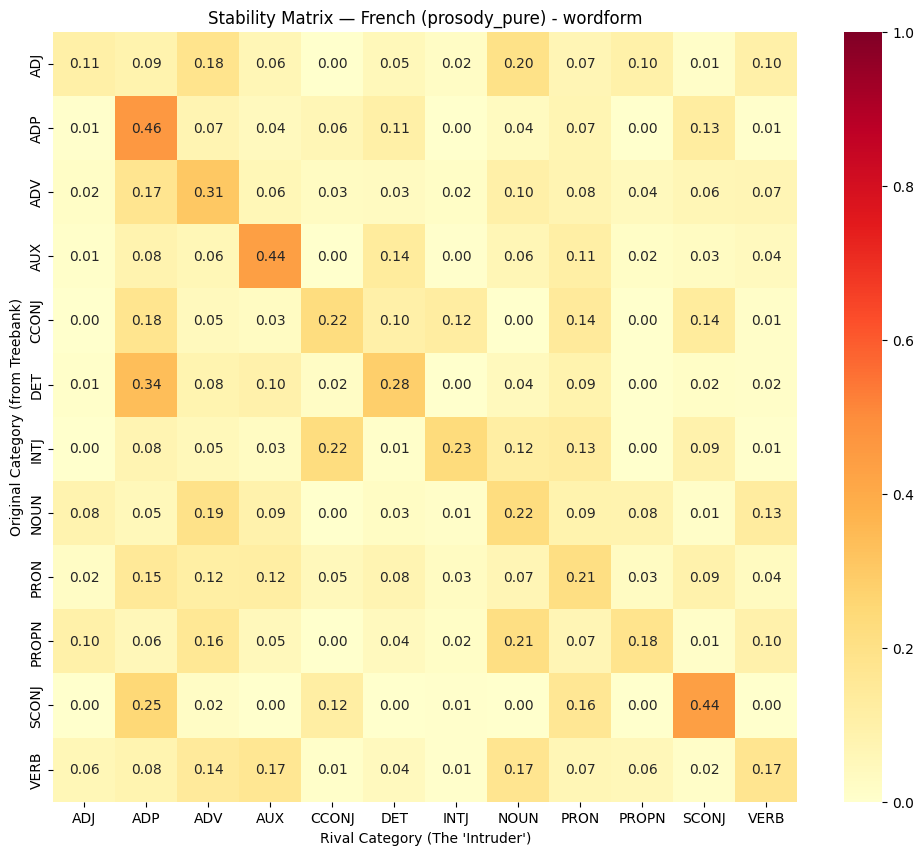

Neighbor,ADJ,ADP,ADV,AUX,CCONJ,DET,INTJ,NOUN,PRON,PROPN,SCONJ,VERB
Original,,,,,,,,,,,,
ADJ,0.107549,0.089218,0.182972,0.063051,0.002773,0.053388,0.021030,0.195692,0.067370,0.101000,0.013140,0.102817
ADP,0.005271,0.460963,0.074397,0.040191,0.063980,0.109283,0.000000,0.035681,0.074071,0.000688,0.128072,0.007403
ADV,0.018562,0.174356,0.308408,0.058640,0.029994,0.034256,0.017884,0.102371,0.076268,0.043692,0.062895,0.068903
AUX,0.010343,0.084244,0.059270,0.440803,0.000000,0.135999,0.004322,0.064883,0.111516,0.017289,0.029822,0.041509
CCONJ,0.000313,0.178702,0.045638,0.028995,0.224595,0.103937,0.123641,0.000772,0.142672,0.000000,0.136177,0.014559
DET,0.007850,0.338483,0.079869,0.097147,0.019720,0.283908,0.002087,0.043902,0.089009,0.002954,0.016570,0.015408
INTJ,0.001345,0.076417,0.051219,0.029762,0.224119,0.009841,0.231705,0.119479,0.129987,0.001900,0.092852,0.005157
NOUN,0.082375,0.052320,0.191672,0.090324,0.002451,0.025806,0.013936,0.223828,0.087551,0.083509,0.012748,0.129225
PRON,0.020305,0.150305,0.116339,0.119509,0.047738,0.075152,0.028985,0.068565,0.212821,0.028183,0.090953,0.038077


In [58]:
# Build a transition matrix for each feature space.
transition_matrices = {
    space: build_transition_matrix(sim, idx2lexunit, category_freqs)
    for space, sim in similarities.items()
}


# Show one — change SPACE to flip view.
SPACE = "prosody_pure"   # "syntactic", "prosodic_syntactic", "prosody_pure", "combined", "prosodic_foot", "prosodic_group", "prosodic_package", "prosodic_period", "prosodic_all_levels"
plot_transition_matrix(
    transition_matrices[SPACE],
    title=f"Stability Matrix — French ({SPACE}) - wordform",
    # drop_categories=("X", "SYM"),   # uncomment to hide noise categories
)
transition_matrices[SPACE]


In [59]:
print(transition_matrices[SPACE])

Neighbor       ADJ       ADP       ADV       AUX     CCONJ       DET  \
Original                                                               
ADJ       0.107549  0.089218  0.182972  0.063051  0.002773  0.053388   
ADP       0.005271  0.460963  0.074397  0.040191  0.063980  0.109283   
ADV       0.018562  0.174356  0.308408  0.058640  0.029994  0.034256   
AUX       0.010343  0.084244  0.059270  0.440803  0.000000  0.135999   
CCONJ     0.000313  0.178702  0.045638  0.028995  0.224595  0.103937   
DET       0.007850  0.338483  0.079869  0.097147  0.019720  0.283908   
INTJ      0.001345  0.076417  0.051219  0.029762  0.224119  0.009841   
NOUN      0.082375  0.052320  0.191672  0.090324  0.002451  0.025806   
PRON      0.020305  0.150305  0.116339  0.119509  0.047738  0.075152   
PROPN     0.098523  0.055241  0.159311  0.048164  0.003210  0.042750   
SCONJ     0.000000  0.246697  0.022111  0.000000  0.118540  0.003140   
VERB      0.060621  0.081467  0.142075  0.166891  0.008665  0.03

In [78]:
def get_top_bridge_words(scores_dict, original_cat, rival_cat, top_n=100):
    """Words from `original_cat` most pulled toward `rival_cat`."""
    matches = [
        {"word": word, "purity": float(d["purity"]), "entropy": float(d["entropy"])}
        for (word, o_cat), d in scores_dict.items()
        if o_cat == original_cat and d["rival_category"] == rival_cat
    ]
    # Lowest combined score first — least pure, highest entropy.
    # matches.sort(key=lambda x: 0.7 * x["purity"] - 0.3 * x["entropy"])
    matches.sort(key=lambda x: x["purity"])
    return [(m["word"], f'{m["purity"]:.2f}', f'{m["entropy"]:.2f}')
            for m in matches[:top_n]]


In [79]:
# ── Pick a feature space and a category pair ──────────────────────────────
SPACE          = "prosody_pure"        # "syntactic" | "prosodic_syntactic" | "prosody_pure" | "combined"
ORIGINAL_CAT   = "VERB"
RIVAL_CAT      = "AUX"

scores = scores_by_space[SPACE]
bridge_words = get_top_bridge_words(scores, ORIGINAL_CAT, RIVAL_CAT)

print(f"Top {ORIGINAL_CAT} → {RIVAL_CAT} bridge words ({SPACE} space):")
print(f"{'Word':<20} {'Purity':>8} {'Entropy':>8}")
for word, purity, ent in bridge_words:
    print(f"{word:<20} {purity:>8} {ent:>8}")


Top VERB → AUX bridge words (prosody_pure space):
Word                   Purity  Entropy
annoncera                0.00     0.78
assure                   0.00     0.49
reviens                  0.00     0.00
travaillé                0.00     1.27
va                       0.00     1.45
ont                      0.00     1.28
pourrait                 0.00     1.24
lu                       0.01     1.37
peut                     0.01     1.41
faut                     0.01     1.45
retrouve                 0.01     1.32
doit                     0.01     1.42
veux                     0.01     1.51
comprend                 0.01     1.33
vas                      0.01     0.82
restent                  0.01     1.40
arrivé                   0.01     1.05
veut                     0.01     1.26
semblait                 0.01     1.63
sais                     0.01     1.03
remettre                 0.01     1.41
appelait                 0.01     0.83
a                        0.01     1.44
avoir         

In [ ]:
def get_pulling_features(
    lex_unit, rival_category,
    feature_matrix, similarity_matrix,
    idx2lexunit, lexunit2idx,
    idx2feature, feature2idx,
    feature_mask=None,
    top_k_features=20,
    sim_threshold=0.7, max_neighbours=20,
):
    """Features pulling `lex_unit` toward `rival_category`.

    Score = (unit's coverage on the feature) / (|unit_value − rival_centroid| + ε).
    Features the unit doesn't use at all (zero coverage) score zero — they
    can't be pulling anything.
    """
    unit_idx = lexunit2idx[lex_unit]
    unit_vector = feature_matrix[unit_idx]

    # Top-k neighbours.
    candidate_idx = np.where(similarity_matrix[unit_idx] >= sim_threshold)[0]
    neighbour_indices = sorted(
        [i for i in candidate_idx if i != unit_idx],
        key=lambda i: similarity_matrix[unit_idx][i],
        reverse=True,
    )[:max_neighbours]

    # Rival centroid: median over rival-category neighbours.
    rival_neighbour_indices = [
        i for i in neighbour_indices if idx2lexunit[i][1] == rival_category
    ]
    if not rival_neighbour_indices:
        print(f"No neighbours of category '{rival_category}' found for {lex_unit}.")
        return []
    rival_centroid = np.median(feature_matrix[rival_neighbour_indices], axis=0)

    feature_differences = np.abs(unit_vector - rival_centroid)
    eps = 1e-6
    scores = np.where(
        unit_vector > 0,
        unit_vector / (feature_differences + eps),
        0.0,
    )

    # Restrict scoring to the active feature space. Without this, neighbours
    # are chosen by (e.g.) syntactic similarity but the top-ranked pulling
    # features can come from any column of the full matrix.
    if feature_mask is not None:
        scores = np.where(feature_mask, scores, 0.0)

    top_idx = np.argsort(scores)[::-1][:top_k_features]
    return [
        {
            "feature":    idx2feature[f_idx],
            "unit_value": unit_vector[f_idx],
            "rival_avg":  rival_centroid[f_idx],
            "diff":       feature_differences[f_idx],
            "score":      scores[f_idx],
        }
        for f_idx in top_idx
        if scores[f_idx] > 0
    ]


In [84]:
def get_pulling_features_by_mass(
    lex_unit, rival_category,
    feature_matrix, similarity_matrix,
    idx2lexunit, lexunit2idx,
    idx2feature, feature2idx,
    feature_mask=None,
    top_k_features=20,
    sim_threshold=0.7, max_neighbours=20,
):
    """Features that actually build the unit↔rival cosine similarity.
 
    Restrict to the active space, L2-normalise the unit (û) and each rival
    neighbour, average the normalised rivals into a direction r̂, then rank
    features by ûᵢ · r̂ᵢ. These contributions sum to the mean cosine similarity
    between the unit and its rival-category neighbours, so `share` tells you how
    much of the overlap each feature is responsible for.
    """
    unit_idx = lexunit2idx[lex_unit]
 
    cols = np.where(feature_mask)[0] if feature_mask is not None \
        else np.arange(feature_matrix.shape[1])
 
    u = feature_matrix[unit_idx, cols].astype(float)
    u_norm = np.linalg.norm(u)
    if u_norm == 0:
        return []
    u_hat = u / u_norm
 
    candidate_idx = np.where(similarity_matrix[unit_idx] >= sim_threshold)[0]
    neighbour_indices = sorted(
        [i for i in candidate_idx if i != unit_idx],
        key=lambda i: similarity_matrix[unit_idx][i], reverse=True,
    )[:max_neighbours]
    rival_neighbour_indices = [
        i for i in neighbour_indices if idx2lexunit[i][1] == rival_category
    ]
    if not rival_neighbour_indices:
        print(f"No neighbours of category '{rival_category}' found for {lex_unit}.")
        return []
 
    rival_block = feature_matrix[np.ix_(rival_neighbour_indices, cols)].astype(float)
    rn = np.linalg.norm(rival_block, axis=1, keepdims=True)
    rn[rn == 0] = 1.0
    rival_hat = (rival_block / rn).mean(axis=0)
 
    contribution = u_hat * rival_hat          # sums to mean cosine similarity
    total = contribution.sum()
 
    order = np.argsort(contribution)[::-1][:top_k_features]
    rows = []
    for local_i in order:
        c = contribution[local_i]
        if c <= 0:
            continue
        g_idx = int(cols[local_i])
        rows.append({
            "feature":      idx2feature[g_idx],
            "unit_value":   float(u[local_i]),
            "rival_dir":    float(rival_hat[local_i]),
            "contribution": float(c),
            "share":        float(c / total) if total > 0 else 0.0,
        })
    return rows

In [85]:
SPACE     = "prosody_pure"
LEX_UNIT  = ('dois', 'VERB')
RIVAL_CAT = "AUX"
 
results = get_pulling_features_by_mass(
    LEX_UNIT, RIVAL_CAT,
    feature_matrix, similarities[SPACE],
    idx2lexunit, lexunit2idx,
    idx2feature, feature2idx,
    feature_mask=SPACE_MASKS[SPACE],
    top_k_features=20,
)
 
print(f"Top features building the {LEX_UNIT} → {RIVAL_CAT} similarity "
      f"({SPACE} space):")
print(f"{'Feature':<48} {'unit':>6}  {'r_dir':>6}  {'contrib':>8}  {'share':>6}")
print("-" * 82)
for r in results:
    print(f"{r['feature']:<48} {r['unit_value']:>6.3f}  {r['rival_dir']:>6.3f}  "
          f"{r['contribution']:>8.4f}  {r['share']:>5.1%}")

Top features building the ('dois', 'VERB') → AUX similarity (prosody_pure space):
Feature                                            unit   r_dir   contrib   share
----------------------------------------------------------------------------------
node:X:own:Package=In                             0.006   0.144    0.0206   2.9%
node:X:prevSyl:AvgHeightGlo=M                     0.006   0.130    0.0187   2.6%
node:X:prevSyl:PitchRangeGlo=L                    0.006   0.125    0.0179   2.5%
node:X:childSyl1:PitchRangeGlo=L                  0.004   0.146    0.0140   2.0%
node:X:childSyl1:AvgHeightGlo=M                   0.004   0.144    0.0137   1.9%
node:X:prev:Package=In                            0.006   0.095    0.0136   1.9%
node:X:childSyl1:SlopeGlo=Flat                    0.004   0.133    0.0127   1.8%
node:X:next:RhythmGroup=Strong                    0.006   0.087    0.0124   1.7%
node:X:prev:Foot=In                               0.006   0.079    0.0113   1.6%
node:X:prev:Group=In    

In [82]:
def get_aggregate_pulling_features(
    scores_dict, original_cat, rival_cat,
    feature_matrix, similarity_matrix,
    idx2lexunit, lexunit2idx,
    idx2feature, feature2idx,
    feature_mask=None,
    top_k_words=10, top_k_features=20,
    sim_threshold=0.7, max_neighbours=20,
):
    """Cross-word aggregate of the pulling features for an `original_cat`
    → `rival_cat` direction.

    A feature appears in the aggregate if it surfaced for at least one bridge
    word. Ranked by how many bridge words it shows up in (robustness), with
    average unit value as a tiebreaker.
    """
    bridge_words = get_top_bridge_words(scores_dict, original_cat, rival_cat,
                                        top_n=top_k_words)
    if not bridge_words:
        print(f"No bridge words found from {original_cat} to {rival_cat}")
        return None

    print(f"Analyzing {len(bridge_words)} bridge words: "
          f"{[w[0] for w in bridge_words]}\n")

    per_feature = {}
    for word, _purity, _entropy in bridge_words:
        lex_unit = (word, original_cat)
        if lex_unit not in lexunit2idx:
            print(f"  WARNING: {lex_unit} not found in lexunit2idx, skipping.")
            continue

        word_features = get_pulling_features(
            lex_unit=lex_unit, rival_category=rival_cat,
            feature_matrix=feature_matrix, similarity_matrix=similarity_matrix,
            idx2lexunit=idx2lexunit, lexunit2idx=lexunit2idx,
            idx2feature=idx2feature, feature2idx=feature2idx,
            feature_mask=feature_mask,
            top_k_features=top_k_features * 2,   # cast wide before aggregating
            sim_threshold=sim_threshold, max_neighbours=max_neighbours,
        )
        for fd in word_features:
            d = per_feature.setdefault(fd["feature"],
                                       {"unit_values": [], "rival_avgs": [], "diffs": []})
            d["unit_values"].append(fd["unit_value"])
            d["rival_avgs"].append(fd["rival_avg"])
            d["diffs"].append(fd["diff"])

    if not per_feature:
        print("No features collected — check bridge words and similarity threshold.")
        return None

    rows = [
        {
            "feature":         fname,
            "count_words":     len(d["unit_values"]),
            "avg_unit_value":  float(np.mean(d["unit_values"])),
            "avg_rival_value": float(np.mean(d["rival_avgs"])),
            "avg_diff":        float(np.mean(d["diffs"])),
            "std_unit_value":  float(np.std(d["unit_values"])),
        }
        for fname, d in per_feature.items()
    ]
    rows.sort(key=lambda r: (r["count_words"], r["avg_unit_value"]), reverse=True)
    return pd.DataFrame(rows[:top_k_features])


In [86]:
def get_aggregate_pulling_features_by_mass(
    scores_dict, original_cat, rival_cat,
    feature_matrix, similarity_matrix,
    idx2lexunit, lexunit2idx,
    idx2feature, feature2idx,
    feature_mask=None,
    top_k_words=10, top_k_features=20,
    sim_threshold=0.7, max_neighbours=20,
):
    bridge_words = get_top_bridge_words(scores_dict, original_cat, rival_cat,
                                        top_n=top_k_words)
    if not bridge_words:
        print(f"No bridge words found from {original_cat} to {rival_cat}")
        return None
 
    print(f"Analyzing {len(bridge_words)} bridge words: "
          f"{[w[0] for w in bridge_words]}\\n")
 
    per_feature = {}
    for word, _p, _e in bridge_words:
        lex_unit = (word, original_cat)
        if lex_unit not in lexunit2idx:
            continue
        feats = get_pulling_features_by_mass(
            lex_unit=lex_unit, rival_category=rival_cat,
            feature_matrix=feature_matrix, similarity_matrix=similarity_matrix,
            idx2lexunit=idx2lexunit, lexunit2idx=lexunit2idx,
            idx2feature=idx2feature, feature2idx=feature2idx,
            feature_mask=feature_mask,
            top_k_features=top_k_features * 3,
            sim_threshold=sim_threshold, max_neighbours=max_neighbours,
        )
        for fd in feats:
            d = per_feature.setdefault(
                fd["feature"],
                {"contribs": [], "unit_values": []},
            )
            d["contribs"].append(fd["contribution"])
            d["unit_values"].append(fd["unit_value"])
 
    if not per_feature:
        print("No features collected — check bridge words and similarity threshold.")
        return None
 
    rows = [{
        "feature":        fname,
        "count_words":    len(d["contribs"]),
        "total_contrib":  float(np.sum(d["contribs"])),
        "avg_contrib":    float(np.mean(d["contribs"])),
        "avg_unit_value": float(np.mean(d["unit_values"])),
    } for fname, d in per_feature.items()]
    rows.sort(key=lambda r: r["total_contrib"], reverse=True)
    return pd.DataFrame(rows[:top_k_features])

In [87]:
SPACE        = "prosody_pure"
ORIGINAL_CAT = "VERB"
RIVAL_CAT    = "AUX"
 
df_mass = get_aggregate_pulling_features_by_mass(
    scores_dict=scores_by_space[SPACE],
    original_cat=ORIGINAL_CAT, rival_cat=RIVAL_CAT,
    feature_matrix=feature_matrix,
    similarity_matrix=similarities[SPACE],
    idx2lexunit=idx2lexunit, lexunit2idx=lexunit2idx,
    idx2feature=idx2feature, feature2idx=feature2idx,
    feature_mask=SPACE_MASKS[SPACE],
    top_k_words=40, top_k_features=25,
)
 
if df_mass is not None:
    print(df_mass.to_string(index=False))

Analyzing 40 bridge words: ['annoncera', 'assure', 'reviens', 'travaillé', 'va', 'ont', 'pourrait', 'lu', 'peut', 'faut', 'retrouve', 'doit', 'veux', 'comprend', 'vas', 'restent', 'arrivé', 'veut', 'semblait', 'sais', 'remettre', 'appelait', 'a', 'avoir', 'ai', 'être', 'parler', 'eu', 'allez', 'avaient', 'entendre', 'allait', 'entend', 'tourniez', 'a~', 'restée', 'rendu', 'sent', 'croyais', 'été']\n
                            feature  count_words  total_contrib  avg_contrib  avg_unit_value
   node:X:childSyl1:PitchRangeGlo=L           39       0.665239     0.017057        0.005598
     node:X:nextSyl:PitchRangeGlo=L           40       0.648028     0.016201        0.005283
              node:X:own:Package=In           40       0.633163     0.015829        0.005232
      node:X:nextSyl:AvgHeightGlo=M           40       0.620251     0.015506        0.005074
    node:X:childSyl1:AvgHeightGlo=M           39       0.614171     0.015748        0.005511
      node:X:prevSyl:AvgHeightGlo=M    

In [83]:
# ── Single-word usage ──────────────────────────────────────────────────────
SPACE        = "prosody_pure"          # "syntactic" | "prosodic_syntactic" | "prosody_pure" | "combined"
LEX_UNIT     = ('dois', 'VERB')
RIVAL_CAT    = "AUX"

results = get_pulling_features(
    LEX_UNIT, RIVAL_CAT,
    feature_matrix, similarities[SPACE],
    idx2lexunit, lexunit2idx,
    idx2feature, feature2idx,
    feature_mask=SPACE_MASKS[SPACE],
    top_k_features=20,
)

print(f"Top features pulling {LEX_UNIT} toward {RIVAL_CAT} ({SPACE} space):")
print(f"{'Feature':<55} {'unit':>6}  {'rival':>6}  {'diff':>6}  {'score':>8}")
print("-" * 90)
for r in results:
    print(
        f"{r['feature']:<55} "
        f"{r['unit_value']:>6.3f}  "
        f"{r['rival_avg']:>6.3f}  "
        f"{r['diff']:>6.3f}  "
        f"{r['score']:>8.2f}"
    )
    


Top features pulling ('dois', 'VERB') toward AUX (prosody_pure space):
Feature                                                   unit   rival    diff     score
------------------------------------------------------------------------------------------
node:X:own:Package=In                                    0.006   0.006   0.001      0.00
node:X:prevSyl:AvgHeightGlo=M                            0.006   0.005   0.001      0.00
node:X:prevSyl:PitchRangeGlo=L                           0.006   0.005   0.002      0.00
node:X:childSyl1:PitchRangeGlo=L                         0.004   0.006   0.001      0.00
node:X:childSyl1:AvgHeightGlo=M                          0.004   0.006   0.001      0.00
node:X:prev:Package=In                                   0.006   0.004   0.003      0.00
node:X:childSyl1:SlopeGlo=Flat                           0.004   0.005   0.001      0.00
node:X:next:RhythmGroup=Strong                           0.006   0.003   0.003      0.00
node:X:prev:Group=In                 

In [70]:
# ── Aggregate usage (the "defining features" of a directional pull) ───────
SPACE        = "prosody_pure"           # "syntactic" | "prosodic_syntactic" | "prosody_pure" | "combined"
ORIGINAL_CAT = "VERB"
RIVAL_CAT    = "AUX"

df_agg = get_aggregate_pulling_features(
    scores_dict=scores_by_space[SPACE],
    original_cat=ORIGINAL_CAT, rival_cat=RIVAL_CAT,
    feature_matrix=feature_matrix,
    similarity_matrix=similarities[SPACE],
    idx2lexunit=idx2lexunit, lexunit2idx=lexunit2idx,
    idx2feature=idx2feature, feature2idx=feature2idx,
    feature_mask=SPACE_MASKS[SPACE],
    top_k_words=5, top_k_features=20,
)

if df_agg is not None:
    print(df_agg.to_string(index=False))


Analyzing 5 bridge words: ['dois', 'mort', 'semblait', 'partent', 'voulez']

                            feature  count_words  avg_unit_value  avg_rival_value  avg_diff  std_unit_value
      node:X:nextSyl:AvgHeightGlo=M            4        0.005507         0.005134  0.000373        0.000351
       node:X:prev:PeriodTone:end=m            4        0.002657         0.002491  0.000166        0.000260
        node:X:own:PeriodTone:end=m            4        0.002657         0.002606  0.000193        0.000260
  node:X:next:GroupTone:magnitude=0            3        0.002769         0.003156  0.000387        0.000200
       node:X:next:PeriodTone:end=m            3        0.002769         0.002666  0.000221        0.000200
    node:X:next:PackageTone:start=m            3        0.002769         0.002443  0.000428        0.000200
   node:X:own:GroupTone:magnitude=1            3        0.002769         0.002310  0.000459        0.000200
 node:X:own:GroupTone:has_peak=True            3        0.0

In [73]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def parse_feature_string(feature_str):
    # Matches node:X:context:rest_of_feature=value
    pattern = r"^node:X:(?P<context>[^:]+):(?P<rest>.+)$"
    match = re.match(pattern, feature_str)
    if not match:
        return {"context": "unknown", "level": "unknown", "feature": feature_str, "value": ""}
    
    context = match.group("context")
    rest = match.group("rest")
    
    if "=" in rest:
        feat_part, val = rest.split("=", 1)
    else:
        feat_part, val = rest, ""
        
    # Classify the prosodic level/type
    level = "Acoustic (Syllable)"
    for lvl in ["Foot", "Group", "Package", "Period", "Prominence", "RhythmGroup"]:
        if lvl in feat_part:
            level = lvl
            break
            
    return {
        "context": context,
        "level": level,
        "clean_feature": feat_part,
        "value": val
    }

parsed_data = [parse_feature_string(f) for f in df_agg['feature']]
df_parsed = pd.DataFrame(parsed_data)

# Combine with your metric scores
df_analysis = pd.concat([df_parsed, df_agg.reset_index(drop=True)], axis=1)

# Where is the strength coming from? (e.g., prev, own, next, childSyl)
print(df_analysis.groupby('context')['count_words'].sum())

# Which structural level is dominating the transition?
print(df_analysis.groupby('level')['count_words'].sum())

context
childSyl1     2
childSyl2     4
next         12
nextSyl       7
own          17
prev         12
prevSyl       2
Name: count_words, dtype: int64
level
Acoustic (Syllable)    15
Foot                    4
Group                  18
Package                 5
Period                 11
Prominence              3
Name: count_words, dtype: int64


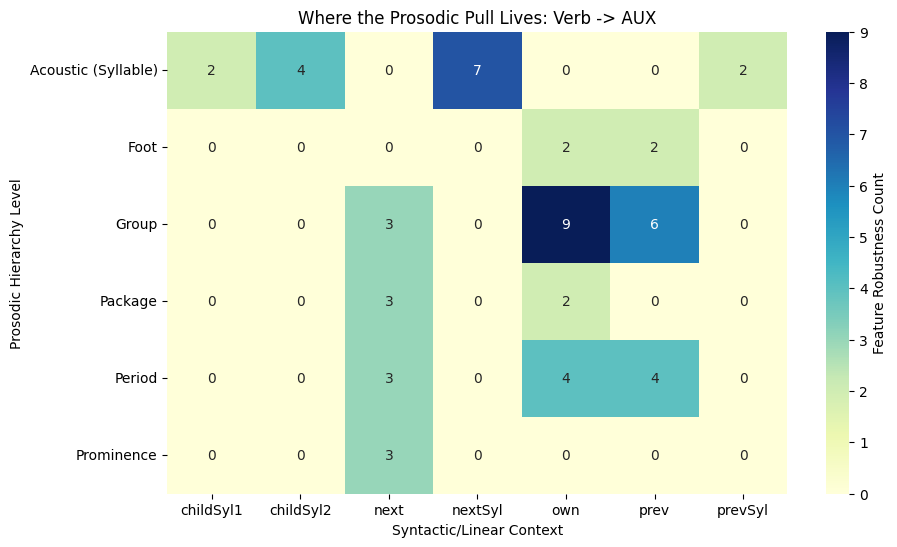

In [74]:
# Pivot to get a matrix of Context vs. Prosodic Level
pivot_df = df_analysis.pivot_table(
    index='level', 
    columns='context', 
    values='count_words', # or 'avg_unit_value'
    aggfunc='sum'
).fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt="g", cbar_kws={'label': 'Feature Robustness Count'})
plt.title("Where the Prosodic Pull Lives: Verb -> AUX")
plt.ylabel("Prosodic Hierarchy Level")
plt.xlabel("Syntactic/Linear Context")
plt.show()

In [77]:
# Filter your df_analysis to see the dominant structural features on 'own'
print("--- Highly Diagnostic 'Group' and 'Period' Features on 'own' ---")
diagnostic_structural = df_analysis[
    (df_analysis['context'] == 'own') & 
    (df_analysis['level'].isin(['Group', 'Period']))
].sort_values(by='count_words', ascending=False)

print(diagnostic_structural[['feature', 'count_words', 'avg_unit_value']].head(10).to_string(index=False))

print("\n--- Highly Diagnostic Acoustic Features on the Word's Syllables ---")
diagnostic_acoustic = df_analysis[
    (df_analysis['context'].isin(['childSyl1', 'childSyl2'])) & 
    (df_analysis['level'] == 'Acoustic (Syllable)')
].sort_values(by='count_words', ascending=False)

print(diagnostic_acoustic[['feature', 'count_words', 'avg_unit_value']].head(10).to_string(index=False))

--- Highly Diagnostic 'Group' and 'Period' Features on 'own' ---
                            feature  count_words  avg_unit_value
        node:X:own:PeriodTone:end=m            4        0.002657
   node:X:own:GroupTone:magnitude=1            3        0.002769
 node:X:own:GroupTone:has_peak=True            3        0.002627
node:X:own:GroupTone:direction=fall            3        0.002397

--- Highly Diagnostic Acoustic Features on the Word's Syllables ---
                         feature  count_words  avg_unit_value
node:X:childSyl2:PitchRangeGlo=L            2        0.005375
  node:X:childSyl1:SlopeGlo=Flat            2        0.005213
 node:X:childSyl2:AvgHeightGlo=M            2        0.004988


In [76]:
print(pivot_df)

context              childSyl1  childSyl2  next  nextSyl  own  prev  prevSyl
level                                                                       
Acoustic (Syllable)        2.0        4.0   0.0      7.0  0.0   0.0      2.0
Foot                       0.0        0.0   0.0      0.0  2.0   2.0      0.0
Group                      0.0        0.0   3.0      0.0  9.0   6.0      0.0
Package                    0.0        0.0   3.0      0.0  2.0   0.0      0.0
Period                     0.0        0.0   3.0      0.0  4.0   4.0      0.0
Prominence                 0.0        0.0   3.0      0.0  0.0   0.0      0.0


In [88]:
def _cell_of(feature_str):
    p = parse_feature_string(feature_str)
    return p["context"], p["level"]
 
 
def background_cell_counts(idx2feature, feature_mask):
    rows = []
    for i, feat in idx2feature.items():
        if feature_mask is not None and not feature_mask[i]:
            continue
        ctx, lvl = _cell_of(feat)
        rows.append({"context": ctx, "level": lvl})
    return (pd.DataFrame(rows)
              .pivot_table(index="level", columns="context",
                           aggfunc="size", fill_value=0))
 
 
def observed_over_expected(df_surfaced, idx2feature, feature_mask,
                           value="total_contrib"):
    """Returns (observed, expected, ratio) DataFrames indexed level × context."""
    parsed = pd.DataFrame([parse_feature_string(f) for f in df_surfaced["feature"]])
    obs_df = parsed[["context", "level"]].copy()
    obs_df["_mass"] = np.asarray(df_surfaced[value].values).ravel()
    observed = obs_df.pivot_table(index="level", columns="context",
                                  values="_mass", aggfunc="sum", fill_value=0.0)
 
    bg = background_cell_counts(idx2feature, feature_mask)
    observed, bg = observed.align(bg, fill_value=0.0)
 
    total_obs, total_bg = observed.values.sum(), bg.values.sum()
    if total_obs == 0 or total_bg == 0:
        return observed, bg * 0.0, observed * 0.0
 
    expected = (bg / total_bg) * total_obs
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = (observed / expected).replace([np.inf, -np.inf], np.nan)
    return observed, expected, ratio

Observed contribution mass per (level × context):
context              childSyl1  childSyl2  childSyl3  childSyl4  childSyl5  childSylExt1   next  nextSyl    own   prev  prevSyl
level                                                                                                                          
Acoustic (Syllable)      1.776      0.826        0.0        0.0        0.0           0.0  0.000    1.747  0.000  0.000    1.484
Foot                     0.000      0.000        0.0        0.0        0.0           0.0  0.000    0.000  0.303  0.307    0.000
Group                    0.000      0.000        0.0        0.0        0.0           0.0  0.251    0.000  0.561  0.258    0.000
Package                  0.000      0.000        0.0        0.0        0.0           0.0  0.664    0.000  0.963  0.644    0.000
Period                   0.000      0.000        0.0        0.0        0.0           0.0  0.000    0.000  0.243  0.000    0.000
Prominence               0.000      0.000        0.0  

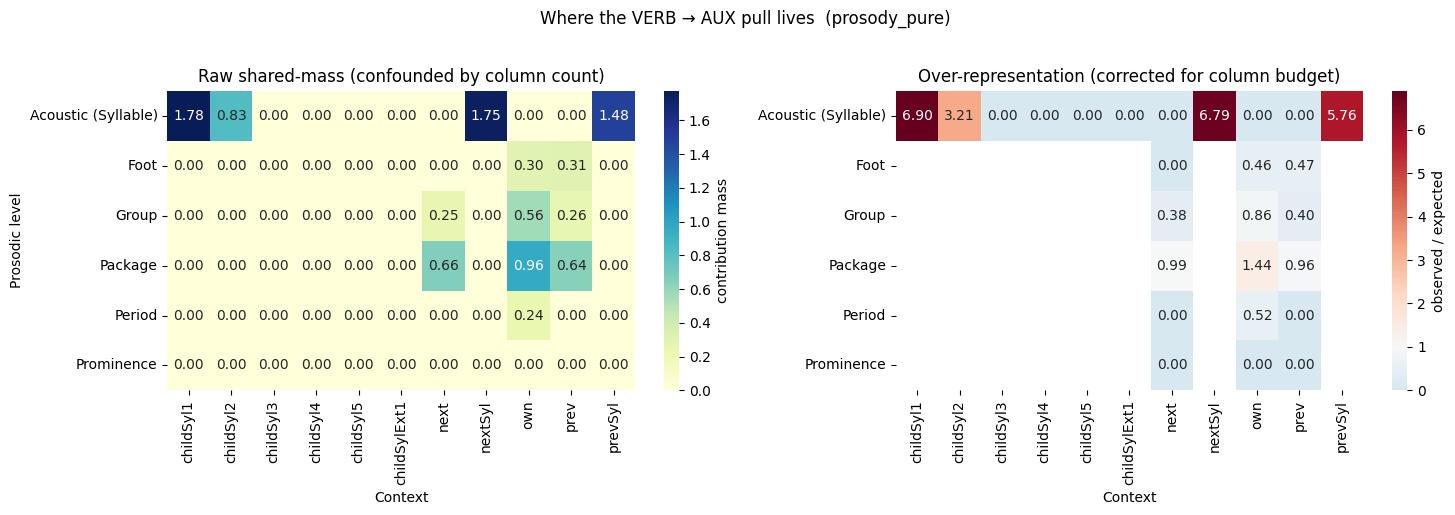

In [89]:
SPACE = "prosody_pure"
 
observed, expected, ratio = observed_over_expected(
    df_mass, idx2feature, SPACE_MASKS[SPACE], value="total_contrib",
)
 
print("Observed contribution mass per (level × context):")
print(observed.round(3).to_string())
print("\\nObserved / Expected  (>1 = over-represented for its column budget):")
print(ratio.round(2).to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(observed, annot=True, fmt=".2f", cmap="YlGnBu",
            cbar_kws={"label": "contribution mass"}, ax=axes[0])
axes[0].set_title("Raw shared-mass (confounded by column count)")
axes[0].set_xlabel("Context"); axes[0].set_ylabel("Prosodic level")
 
sns.heatmap(ratio, annot=True, fmt=".2f", cmap="RdBu_r", center=1.0,
            cbar_kws={"label": "observed / expected"}, ax=axes[1])
axes[1].set_title("Over-representation (corrected for column budget)")
axes[1].set_xlabel("Context"); axes[1].set_ylabel("")
plt.suptitle(f"Where the VERB → AUX pull lives  ({SPACE})", y=1.02)
plt.tight_layout()
plt.show()

In [90]:
# Each index sums the coverage of the columns whose names contain any of its
# substrings, giving a per-unit RATE for that prosodic property. Confirm the
# substrings hit real columns with the audit cell below before trusting the plot.
 
INDEX_DEFS = {
    "weak foot":            [":own:FootType=Weak"],
    "non-final in group":   [":own:Group=Begin", ":own:Group=In"],
    "non-final in package": [":own:Package=Begin", ":own:Package=In"],
    "weak final prominence":[":own:ProminenceFinal=Weak"],
    "no salient peak":      [":own:FootTone:has_peak=False",
                             ":own:GroupTone:has_peak=False"],
    "short syllables":      [":childSyl1:Duration=Dur_short",
                             ":childSyl2:Duration=Dur_short"],
}
 
 
def audit_index_columns(idx2feature, feature_mask, index_defs=INDEX_DEFS):
    active = {i: f for i, f in idx2feature.items()
              if feature_mask is None or feature_mask[i]}
    for name, subs in index_defs.items():
        hits = sorted({f for f in active.values() if any(s in f for s in subs)})
        print(f"{name:<24} → {len(hits)} column(s)")
        for h in hits:
            print(f"    {h}")
 
 
print("Index → columns matched in the prosody_pure space:\\n")
audit_index_columns(idx2feature, SPACE_MASKS["prosody_pure"])

Index → columns matched in the prosody_pure space:\n
weak foot                → 1 column(s)
    node:X:own:FootType=Weak
non-final in group       → 2 column(s)
    node:X:own:Group=Begin
    node:X:own:Group=In
non-final in package     → 2 column(s)
    node:X:own:Package=Begin
    node:X:own:Package=In
weak final prominence    → 1 column(s)
    node:X:own:ProminenceFinal=Weak
no salient peak          → 0 column(s)
short syllables          → 2 column(s)
    node:X:childSyl1:Duration=Dur_short
    node:X:childSyl2:Duration=Dur_short


In [91]:
def unit_indices(lex_units, feature_matrix, lexunit2idx, idx2feature,
                 index_defs=INDEX_DEFS):
    name2cols = {name: [i for i, f in idx2feature.items()
                        if any(s in f for s in subs)]
                 for name, subs in index_defs.items()}
    rows = []
    for lu in lex_units:
        if lu not in lexunit2idx:
            continue
        vec = feature_matrix[lexunit2idx[lu]]
        row = {"word": lu[0], "pos": lu[1]}
        for name, cols in name2cols.items():
            row[name] = float(vec[cols].sum()) if cols else np.nan
        rows.append(row)
    return pd.DataFrame(rows)
 
 
def build_three_groups(scores_dict, original_cat, rival_cat,
                       lexunit2idx, n_bridge=40, stable_purity=0.8):
    bridge = [(w, original_cat)
              for w, _p, _e in get_top_bridge_words(scores_dict, original_cat,
                                                    rival_cat, top_n=n_bridge)
              if (w, original_cat) in lexunit2idx]
    rival, stable = [], []
    for (word, cat), d in scores_dict.items():
        if cat == rival_cat:
            rival.append((word, cat))
        elif cat == original_cat and d["purity"] >= stable_purity:
            stable.append((word, cat))
    return bridge, rival, stable
 
 
SPACE        = "prosody_pure"
ORIGINAL_CAT = "VERB"
RIVAL_CAT    = "AUX"
 
bridge, rival, stable = build_three_groups(
    scores_by_space[SPACE], ORIGINAL_CAT, RIVAL_CAT,
    lexunit2idx, n_bridge=40, stable_purity=0.8,
)
print(f"bridge {ORIGINAL_CAT}: {len(bridge)}   "
      f"{RIVAL_CAT}: {len(rival)}   stable {ORIGINAL_CAT}: {len(stable)}")
 
frames = []
for gname, group in [(f"bridge {ORIGINAL_CAT}", bridge),
                     (RIVAL_CAT, rival),
                     (f"stable {ORIGINAL_CAT}", stable)]:
    d = unit_indices(group, feature_matrix, lexunit2idx, idx2feature)
    d["group"] = gname
    frames.append(d)
 
group_df = pd.concat(frames, ignore_index=True)
group_order = [f"bridge {ORIGINAL_CAT}", RIVAL_CAT, f"stable {ORIGINAL_CAT}"]
means = group_df.groupby("group")[list(INDEX_DEFS)].mean().reindex(group_order)
print("\\nMean index value per group:")
print(means.round(3).to_string())

bridge VERB: 40   AUX: 40   stable VERB: 68
\nMean index value per group:
             weak foot  non-final in group  non-final in package  weak final prominence  no salient peak  short syllables
group                                                                                                                    
bridge VERB      0.004               0.004                 0.006                  0.002              NaN            0.005
AUX              0.004               0.004                 0.006                  0.002              NaN            0.004
stable VERB      0.003               0.002                 0.004                  0.003              NaN            0.004


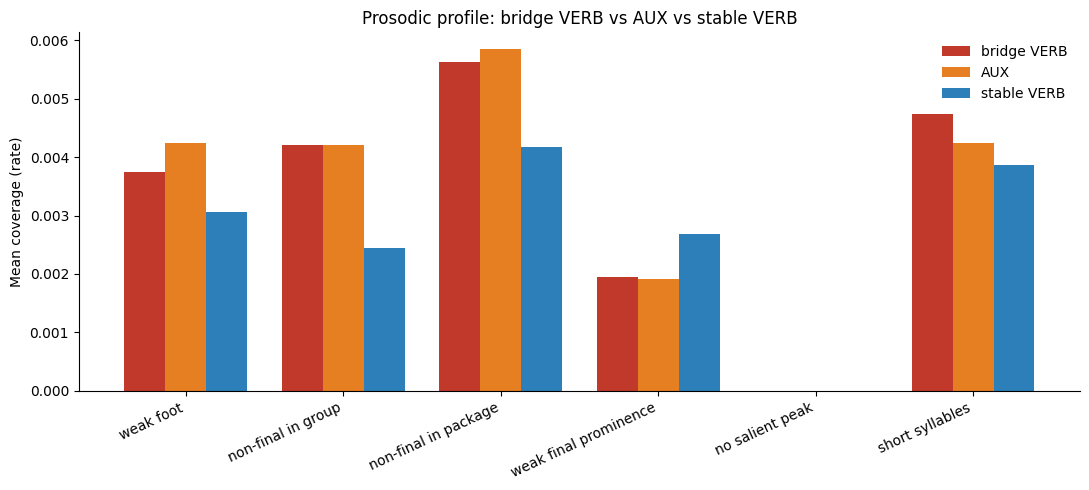

In [92]:
indices = list(INDEX_DEFS)
x = np.arange(len(indices))
width = 0.26
colors = {f"bridge {ORIGINAL_CAT}": "#c0392b",
          RIVAL_CAT:                "#e67e22",
          f"stable {ORIGINAL_CAT}": "#2c7fb8"}
 
fig, ax = plt.subplots(figsize=(11, 5))
for k, gname in enumerate(group_order):
    ax.bar(x + (k - 1) * width, means.loc[gname].values, width,
           label=gname, color=colors[gname])
ax.set_xticks(x)
ax.set_xticklabels(indices, rotation=25, ha="right")
ax.set_ylabel("Mean coverage (rate)")
ax.set_title(f"Prosodic profile: bridge {ORIGINAL_CAT} vs {RIVAL_CAT} "
             f"vs stable {ORIGINAL_CAT}")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

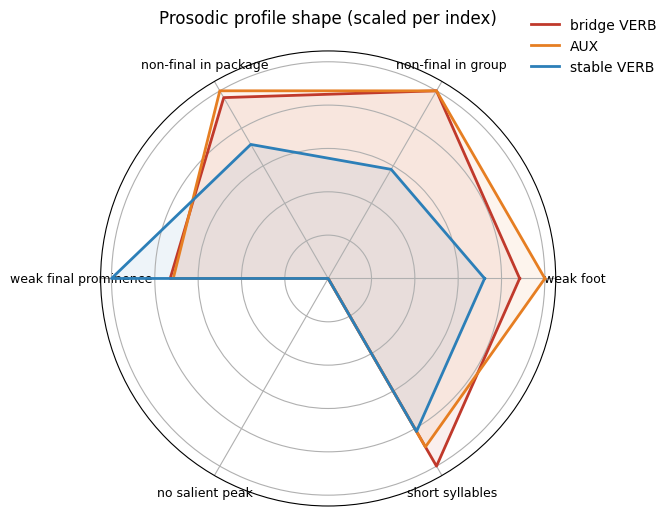

In [93]:
labels = list(INDEX_DEFS)
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]
 
# Scale each index to [0, 1] across groups so axes are comparable.
scaled = means.copy()
for col in labels:
    hi = scaled[col].max()
    scaled[col] = scaled[col] / hi if hi > 0 else 0.0
 
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for gname in group_order:
    vals = scaled.loc[gname, labels].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, label=gname, color=colors[gname], linewidth=2)
    ax.fill(angles, vals, color=colors[gname], alpha=0.08)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels([])
ax.set_title(f"Prosodic profile shape (scaled per index)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
def calculate_weighted_stability(transition_matrix, category_counts):
    """Weighted average of the diagonal of the transition matrix.

    transition_matrix : square, row-stochastic, indexed by POS.
    category_counts   : dict / Series mapping POS → token count (or any
                         consistent weight).
    """
    categories = transition_matrix.index
    stability_scores = pd.Series(np.diag(transition_matrix), index=categories)
    weights = pd.Series(category_counts).reindex(categories).fillna(0)
    total_weight = weights.sum()
    if total_weight == 0:
        return 0.0
    return (stability_scores * weights).sum() / total_weight


# WAS for every feature space.
for space, tm in transition_matrices.items():
    was = calculate_weighted_stability(tm, category_freqs)
    print(f"WAS ({space:<9}): {was:.4f}")


WAS (syntactic): 0.2317
WAS (prosodic_syntactic): 0.2649
WAS (prosody_pure): 0.2152
WAS (combined ): 0.2652


In [ ]:
def permutation_null(similarity, idx2lexunit, n_permutations=200, seed=0):
    rng = np.random.default_rng(seed)
    pos_labels = np.array([lu[1] for lu in idx2lexunit.values()])
    lemmas     = [lu[0] for lu in idx2lexunit.values()]

    # category_freqs depends only on the count of each label, which is
    # preserved under permutation, so we can compute it once.
    cat_counts = Counter(pos_labels)
    n_total = len(pos_labels)
    cat_freqs = {c: k / n_total for c, k in cat_counts.items()}

    null_matrices = []
    for _ in range(n_permutations):
        shuffled = rng.permutation(pos_labels)
        idx2lex_perm = {i: (lemmas[i], shuffled[i]) for i in range(len(lemmas))}
        m = build_transition_matrix(similarity, idx2lex_perm, cat_freqs)
        null_matrices.append(m)

    # Align all matrices on the same category set
    all_cats = sorted(set().union(*[m.index for m in null_matrices]))
    aligned  = [m.reindex(index=all_cats, columns=all_cats, fill_value=0)
                for m in null_matrices]
    stack    = np.stack([m.values for m in aligned])      # shape (n_perm, k, k)
    return (pd.DataFrame(stack.mean(axis=0), index=all_cats, columns=all_cats),
            pd.DataFrame(stack.std(axis=0),  index=all_cats, columns=all_cats))

null_mean, null_std = permutation_null(similarities["prosodic_syntactic"], idx2lexunit)
observed = transition_matrices["prosodic_syntactic"]
z_scores = (observed - null_mean) / null_std.replace(0, np.nan)

In [ ]:
print("Z-scores for prosodic transition matrix vs. permutation null:")
print(z_scores)

Z-scores for prosodic transition matrix vs. permutation null:
            ADJ       ADP       ADV        AUX     CCONJ       DET      INTJ  \
ADJ   -0.487792  0.563539  6.117781  -0.378966 -0.476267  0.370383 -0.354018   
ADP   -2.670123  9.795342 -2.217683   0.649976 -0.688822 -1.173021 -1.007572   
ADV   -2.918645  0.618905  7.520125   0.104578  0.385292  0.765073 -0.750920   
AUX   -0.738386 -0.075128 -0.801010        NaN -0.264067 -0.445572 -0.338017   
CCONJ -1.624889 -0.688358 -0.402994  -0.207690  6.080297  0.454826  2.035524   
DET   -2.110097  0.116278  0.922987  -0.400575  0.665268  5.941281 -0.765789   
INTJ  -2.311436 -0.119624 -1.079145  -0.260776  3.759388  0.306025  5.583558   
NOUN  -3.898286  1.212956 -2.024968   2.010691 -0.903647 -1.567484 -1.240877   
NUM         NaN       NaN       NaN        NaN       NaN       NaN       NaN   
PRON  -2.308797  0.860293  0.300791  -0.005364  2.498797  0.436178 -0.062136   
PROPN -1.109435  1.536659  1.660736   0.580659 -0.797868 -

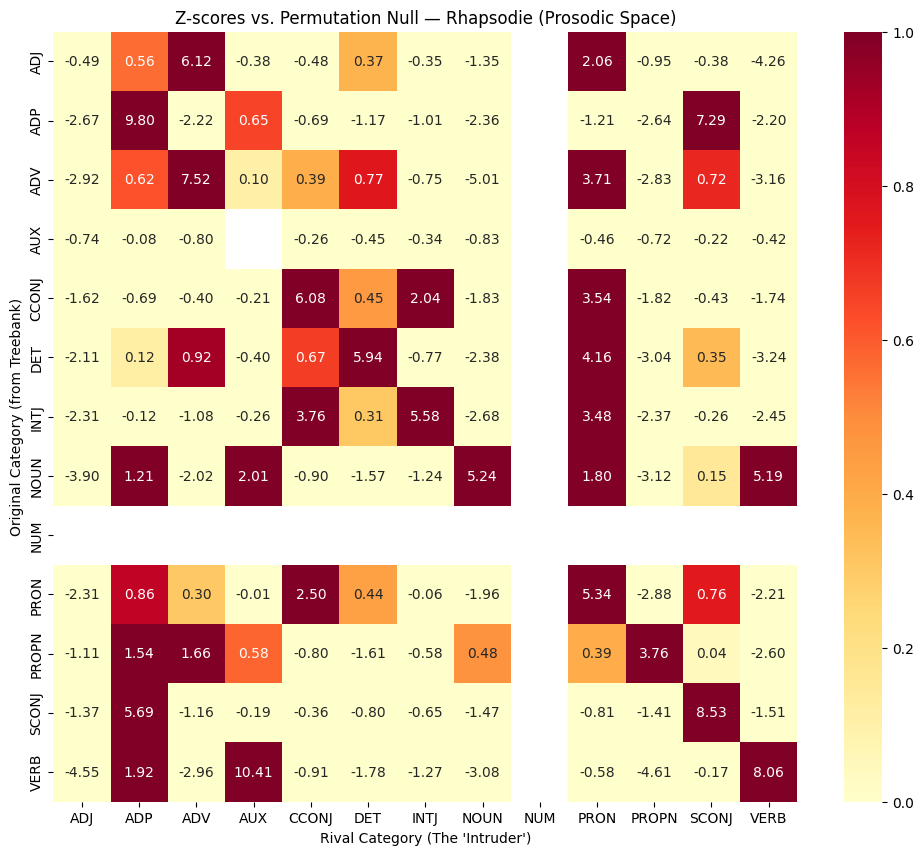

In [ ]:
plot_transition_matrix(
    z_scores,
    title="Z-scores vs. Permutation Null — Rhapsodie (Prosodic Space)",
    drop_categories=("X", "SYM"),   # hide noise categories
)

In [ ]:
# ── Prosodic profile & contour sketch ─────────────────────────────────────
# Turn a pulling-features DataFrame into (a) a compact profile table indexed
# by acoustic dimension × syllable position, and (b) a schematic pitch
# contour drawn as line segments across the prev / own / next syllables.
# The idea is to make cross-category overlaps interpretable at a glance,
# rather than reading raw feature lists.

import matplotlib.pyplot as plt


def _parse_feature(feat):
    """'node:X:childSyl1:AvgHeightGlo=M' → ('childSyl1', 'AvgHeightGlo', 'M')."""
    if not feat.startswith('node:X:') or '=' not in feat:
        return None
    lhs, val = feat[len('node:X:'):].rsplit('=', 1)
    parts = lhs.split(':')
    if len(parts) < 2:
        return None
    return parts[0], ':'.join(parts[1:]), val


# Syllable positions in temporal order (prev → own → next).
SYLLABLE_POSITIONS = ('prev', 'prevSyl', 'own' 'childSyl1', 'childSyl2', 'childSyl3', 'nextSyl', 'next')

# Group the many prosodic feature dimensions into interpretable acoustic
# categories. The Glo / Loc variants (global vs local scope) are lumped
# together since they measure the same underlying acoustic property.
DIM_GROUPS = {
    'pitch height': ('AvgHeightGlo', 'AvgHeightLoc',
                     'SemitonesFromUtteranceMean', 'MeanF0', 'MeanF0Step'),
    'pitch range':  ('PitchRangeGlo', 'PitchRangeLoc'),
    'slope':        ('Slope', 'SlopeGlo', 'SlopeLoc'),
    'duration':     ('Duration',),
    'amplitude':    ('AvgAmplitude', 'MaxAmplitude'),
}
_dim_to_group = {d: g for g, dims in DIM_GROUPS.items() for d in dims}


def _classify(feat):
    """(position, group, dimension, value) if this is a syllable-level feature."""
    p = _parse_feature(feat)
    if p is None:
        return None
    position, dimension, value = p
    if position not in SYLLABLE_POSITIONS:
        return None
    group = _dim_to_group.get(dimension)
    if group is None:
        return None
    return position, group, dimension, value


def build_profile_table(pulling_df, top_k_per_cell=2):
    """
    From a pulling-features DataFrame, produce a compact table indexed by
    acoustic dimension × syllable position. Each cell shows the top-k
    dominant feature values, ranked by aggregate weight (avg_unit_value ×
    count_words).
    """
    rows = []
    for _, r in pulling_df.iterrows():
        cls = _classify(r['feature'])
        if cls is None:
            continue
        pos, group, _, value = cls
        rows.append({
            'position': pos, 'group': group, 'value': value,
            'weight': r['avg_unit_value'] * r['count_words'],
        })
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)

    positions_seen = [p for p in SYLLABLE_POSITIONS if p in df['position'].unique()]
    groups_seen    = [g for g in DIM_GROUPS       if g in df['group'].unique()]

    table = pd.DataFrame(index=groups_seen, columns=positions_seen, dtype=object)
    for group in groups_seen:
        for pos in positions_seen:
            sub = df[(df['position'] == pos) & (df['group'] == group)]
            if sub.empty:
                table.loc[group, pos] = '—'
            else:
                agg = sub.groupby('value')['weight'].sum().sort_values(ascending=False)
                table.loc[group, pos] = ', '.join(agg.head(top_k_per_cell).index.tolist())
    return table


# Numeric mappings for drawing the sketch.
_HEIGHT   = {'L': 1, 'M': 2, 'H': 3,
             'F0_low': 1, 'F0_mid': 2, 'F0_high': 3}
_DURATION = {'Dur_short': 0.5, 'Dur_mid': 0.8, 'Dur_long': 1.2}
_SLOPE    = {'Flat': 0.0, 'Rise': 0.5, 'Fall': -0.5}
_RANGE    = {'L': 0.35, 'M': 0.60, 'H': 0.90}



def _profile_with_confidence(pulling_df):
    """Return {position: {group: {'top', 'alt', 'confidence'}}}.
 
    `confidence` is the top value's share of the total weight for that
    (position, group). A confidence of 1.0 means one value dominates
    completely; 0.5 means the top and alt are tied.
    """
    rows = []
    for _, r in pulling_df.iterrows():
        cls = _classify(r['feature'])
        if cls is None:
            continue
        pos, group, _, value = cls
        rows.append({
            'position': pos, 'group': group, 'value': value,
            'weight': r['avg_unit_value'] * r['count_words'],
        })
    if not rows:
        return {}
    df = pd.DataFrame(rows)
    result = {}
    for (pos, group), sub in df.groupby(['position', 'group']):
        agg = sub.groupby('value')['weight'].sum().sort_values(ascending=False)
        top_val = agg.index[0]
        top_w   = agg.iloc[0]
        total   = agg.sum()
        confidence = top_w / total if total > 0 else 1.0
        alt_val = agg.index[1] if len(agg) > 1 else None
        result.setdefault(pos, {})[group] = {
            'top': top_val, 'alt': alt_val, 'confidence': float(confidence),
        }
    return result


# def _dominant_values(pulling_df):
#     """Return {position: {group: dominant_value}} from pulling features."""
#     rows = []
#     for _, r in pulling_df.iterrows():
#         cls = _classify(r['feature'])
#         if cls is None:
#             continue
#         pos, group, _, value = cls
#         rows.append({
#             'position': pos, 'group': group, 'value': value,
#             'weight': r['avg_unit_value'] * r['count_words'],
#         })
#     if not rows:
#         return {}
#     df = pd.DataFrame(rows)
#     result = {}
#     for (pos, group), sub in df.groupby(['position', 'group']):
#         top_value = sub.groupby('value')['weight'].sum().idxmax()
#         result.setdefault(pos, {})[group] = top_value
#     return result


def sketch_contour(pulling_df, title=None, ax=None,
                   uncertainty_threshold=0.65, show_uncertainty=True):
    """
    Draw a schematic prosodic contour from a pulling-features DataFrame.
    Each syllable becomes a line segment:
      - horizontal position and width : temporal order + duration
      - vertical position             : pitch height
      - line slope                    : direction (rise / flat / fall)
      - shaded band                   : pitch range around the pitch trajectory
 
    When a (syllable, dimension) has a top value that doesn't clearly
    dominate (confidence < `uncertainty_threshold`), the alternative
    value is shown as a lighter dashed indicator:
      - alt slope    → dashed line at the alternative trajectory
      - alt duration → dashed vertical tick at the alternative endpoint
      - alt height   → dashed horizontal line at the alternative pitch level
    The main solid line is also drawn at reduced opacity to signal that
    the value is contested.
    """
    dom = _profile_with_confidence(pulling_df)
    if not dom:
        print("No syllable-level features found in pulling table.")
        return
 
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 3.6))
 
    x = 0
    for pos in SYLLABLE_POSITIONS:
        if pos not in dom:
            continue
        vals = dom[pos]
 
        def _v(group, default):
            info = vals.get(group)
            if info is None:
                return default, None, 1.0
            return info['top'], info['alt'], info['confidence']
 
        h_val, h_alt, h_conf = _v('pitch height', 'M')
        r_val, _,     _      = _v('pitch range',  'M')
        s_val, s_alt, s_conf = _v('slope',        'Flat')
        d_val, d_alt, d_conf = _v('duration',     'Dur_mid')
 
        h = _HEIGHT.get(h_val, 2)
        w = _DURATION.get(d_val, 0.8)
        s = _SLOPE.get(s_val, 0.0)
        r = _RANGE.get(r_val, 0.5)
        # Compute alt widths
        w_alt = None
        if (show_uncertainty and d_conf < uncertainty_threshold
                and d_alt is not None and d_alt in _DURATION):
            w_alt = _DURATION[d_alt]

        is_own = (pos == 'childSyl1')
        color  = '#2166ac' if is_own else '#67a9cf'
        lw     = 4 if is_own else 3
 
        y_start = h - s / 2
        y_end   = h + s / 2
 
        # Pitch range band — wider and with an edge outline for visibility.
        ax.fill_between([x, x + w],
                        [y_start - r/2, y_end - r/2],
                        [y_start + r/2, y_end + r/2],
                        color=color, alpha=0.28,
                        edgecolor=color, linewidth=0.6)
 
        # Alt duration indicator: dashed vertical tick at the alt endpoint,
        # placed just below the range band so it doesn't overlap the pitch line.
        if w_alt is not None:
            tick_x = x + w_alt
            tick_y = y_start - r/2 - 0.04 + (y_end - y_start) * w_alt / w if w > 0 else y_start
            ax.plot([tick_x, tick_x],
                    [tick_y - 0.12, tick_y + 0.08],
                    color=color, linewidth=1.5, alpha=0.6,
                    linestyle=(0, (2, 2)))

        # Main slope line — dimmed if slope is contested
        main_alpha = 0.95 if s_conf >= uncertainty_threshold else 0.65
        ax.plot([x, x + w], [y_start, y_end],
                color=color, linewidth=lw, alpha=main_alpha,
                solid_capstyle='round')

        # Alt slope: dashed line at the alternative trajectory
        if (show_uncertainty and s_conf < uncertainty_threshold
                and s_alt is not None and s_alt in _SLOPE):
            s_alt_val = _SLOPE[s_alt]
            y_alt_start = h - s_alt_val / 2
            y_alt_end   = h + s_alt_val / 2
            ax.plot([x, x + w], [y_alt_start, y_alt_end],
                    color=color, linewidth=lw - 1, alpha=0.4,
                    linestyle=(0, (4, 3)), solid_capstyle='round')

        # Alt pitch height: dashed horizontal at the alt height level
        if (show_uncertainty and h_conf < uncertainty_threshold
                and h_alt is not None and h_alt in _HEIGHT):
            h_alt_val = _HEIGHT[h_alt]
            if abs(h_alt_val - h) >= 1:  # only draw if actually different
                ax.plot([x, x + w], [h_alt_val, h_alt_val],
                        color=color, linewidth=1.5, alpha=0.4,
                        linestyle=(0, (3, 3)))

 
     # Syllable label
        label = {'prevSyl': 'prev', 'childSyl1': 'own',
                 'childSyl2': 'own₂', 'childSyl3': 'own₃',
                 'nextSyl': 'next'}[pos]
        ax.text(x + max(w, w_alt or w) / 2, 0.15, label,
                ha='center', va='center', fontsize=10,
                color=color, weight='bold' if is_own else 'normal')

        # Advance by max of main and alt duration
        x += max(w, w_alt or w) + 0.2
 
    ax.set_ylim(-0.2, 3.8)
    ax.set_xlim(-0.2, max(x, 1))
    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels(['low', 'mid', 'high'])
    ax.set_ylabel('pitch')
    ax.set_xticks([])
    for spine in ('top', 'right', 'bottom'):
        ax.spines[spine].set_visible(False)
    ax.grid(True, axis='y', alpha=0.2, linestyle='--')
    if title:
        ax.set_title(title, fontsize=11, pad=10)
    if standalone:
        plt.tight_layout()

Analyzing 7 bridge words: ["quelqu'un", 'rien', 'personne', 'celui-là', 'quand', 'aucun', 'autre']

Acoustic profile of PRON → ADV overlap (prosody_pure):

              prevSyl childSyl2 nextSyl
pitch height        M         M       M
pitch range         L         L       L
slope            Flat         —    Flat
duration      Dur_mid         —       —



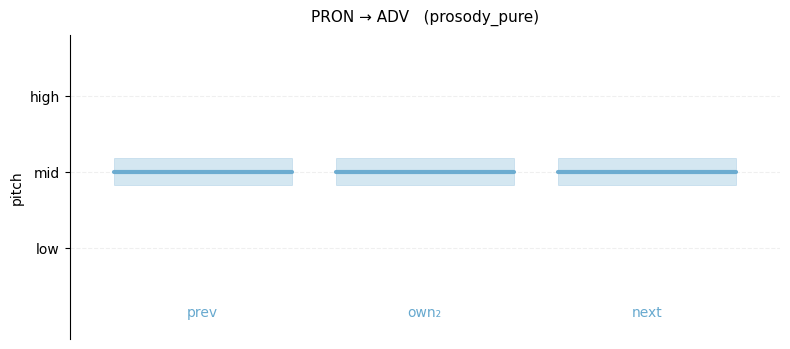

In [ ]:
# ── Profile + sketch for a single cross-category overlap ─────────────────
SPACE        = "prosody_pure"
ORIGINAL_CAT = "PRON"
RIVAL_CAT    = "ADV"

df_agg = get_aggregate_pulling_features(
    scores_dict=scores_by_space[SPACE],
    original_cat=ORIGINAL_CAT, rival_cat=RIVAL_CAT,
    feature_matrix=feature_matrix,
    similarity_matrix=similarities[SPACE],
    idx2lexunit=idx2lexunit, lexunit2idx=lexunit2idx,
    idx2feature=idx2feature, feature2idx=feature2idx,
    feature_mask=SPACE_MASKS[SPACE],
    top_k_words=7, top_k_features=40,
)

profile = build_profile_table(df_agg)
print(f"Acoustic profile of {ORIGINAL_CAT} → {RIVAL_CAT} overlap ({SPACE}):\n")
print(profile.to_string())
print()

sketch_contour(df_agg, title=f"{ORIGINAL_CAT} → {RIVAL_CAT}   ({SPACE})")
plt.show()

Analyzing 7 bridge words: ["quelqu'un", 'rien', 'personne', 'celui-là', 'quand', 'aucun', 'autre']

Analyzing 1 bridge words: ['puisque']



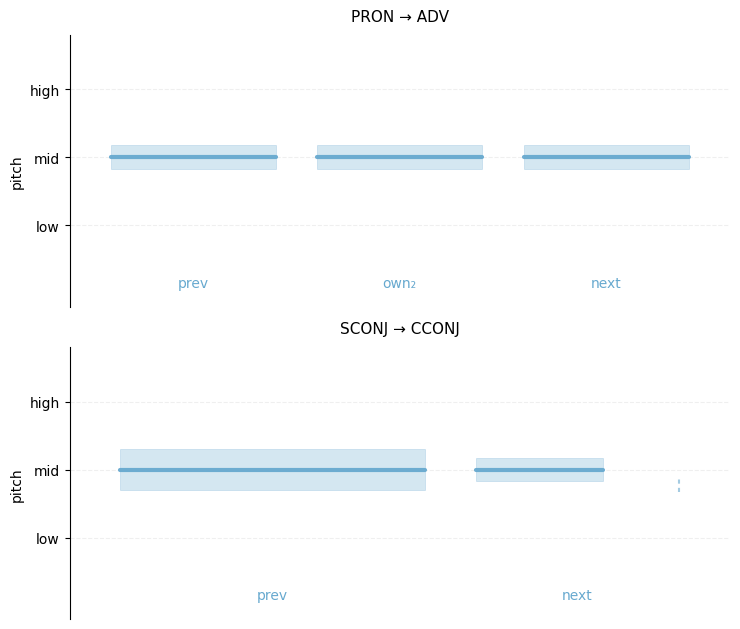

In [ ]:
# ── Compare two overlaps side-by-side ─────────────────────────────────────
# Useful for checking whether two rival attractions share the same acoustic
# gesture (e.g. CCONJ → SCONJ vs SCONJ → CCONJ) or diverge.
SPACE = "prosody_pure"
OVERLAPS = [
    ("PRON", "ADV"),
    ("SCONJ", "CCONJ"),
]

fig, axes = plt.subplots(len(OVERLAPS), 1, figsize=(7.5, 3.2 * len(OVERLAPS)),
                         squeeze=False)
for ax, (orig, rival) in zip(axes.flat, OVERLAPS):
    df_agg = get_aggregate_pulling_features(
        scores_dict=scores_by_space[SPACE],
        original_cat=orig, rival_cat=rival,
        feature_matrix=feature_matrix,
        similarity_matrix=similarities[SPACE],
        idx2lexunit=idx2lexunit, lexunit2idx=lexunit2idx,
        idx2feature=idx2feature, feature2idx=feature2idx,
        feature_mask=SPACE_MASKS[SPACE],
        top_k_words=7, top_k_features=40,
    )
    if df_agg is None or df_agg.empty:
        ax.set_title(f"{orig} → {rival}: no bridge words")
        ax.axis('off')
        continue
    sketch_contour(df_agg, title=f"{orig} → {rival}", ax=ax)
plt.tight_layout()
plt.show()